# Прогноз массы зелёных морских черепах `Chelonia mydas` по данным TurtleCV


- Придумайте тетрадке заголовок, который хорошо описывает решаемую задачу.
- Кратко, но понятно опишите решаемую задачу.

В этой работе я собираю линейную модель, которая по размерам панциря, головы и ласт оценивает массу зелёной морской черепахи без обычного взвешивания. Для центра реабилитации это полезно по простой причине: чем реже приходится поднимать крупное и часто травмированное животное, тем меньше стресс для черепахи и тем безопаснее работа для людей.

Поэтому ноутбук начинается не с моделей, а с проверки самих данных. Сначала я разбираю пропуски, дубли и ошибки в измерениях, потом сравниваю несколько линейных подходов и выбираю модель, которая даёт небольшую ошибку в килограммах и на валидации, и на тесте.



## Постановка задачи машинного обучения

- Опишите, какую задачу нужно решить: регрессии или классификации.
- Выберите поле, которое станет целевой переменной.
- Назовите метрики качества модели, которые планируете использовать.
- Опишите критерии успешности проекта с опорой на метрики.

Это задача **регрессии**: нужно предсказать непрерывную целевую переменную `weight` по данным TurtleCV. В работе я беру только наблюдения по `Chelonia mydas`, потому что именно для этого вида в задании ожидается первый рабочий вариант модели.

Главный ориентир качества здесь `MAE`, потому что он сразу переводится в понятную для центра величину - среднюю ошибку в килограммах. Отдельно смотрю `MAE` на взрослых особях с массой `50-150` кг: именно для этого диапазона задан рабочий порог `не более 5 кг`. Дополнительно считаю `MAPE`, чтобы видеть относительную ошибку для черепах разного размера, и `R²`, потому что итоговая модель должна объяснять почти всю вариативность массы. Данные делю на `train`, `validation` и `test` в пропорции `60/20/20`, а всю предобработку считаю только по обучающей части, чтобы не подмешивать в модель лишнюю информацию.



## Подключение и настройка библиотек

В блоке кода ниже, помимо уже указанных библиотек, импортируйте все остальные, которые планируете использовать для проекта.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge, SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

RANDOM_STATE = 42
TARGET_COLUMN = 'weight'
SPECIES_COLUMN = 'binomial_name'
PRIMARY_DATA_PATH = Path('/datasets/turtles.csv')
LOCAL_DATA_PATH = Path('turtles.csv')
FALLBACK_DATA_URL = 'https://code.s3.yandex.net/datasets/turtles.csv'
FLIPPER_LENGTH_COLUMNS = [f'flipper_length_{index}' for index in range(1, 5)]
FLIPPER_WIDTH_COLUMNS = [f'flipper_width_{index}' for index in range(1, 5)]

FEATURE_LABELS = {
    'id': 'Идентификатор записи (id)',
    'registration_number': 'Регистрационный номер (registration_number)',
    'timestamp': 'Метка времени (timestamp)',
    'binomial_name': 'Вид в исходных данных (binomial_name)',
    'species_norm': 'Нормализованное название вида (species_norm)',
    'shell_crack': 'Трещины панциря (shell_crack)',
    'shell_length': 'Длина панциря (shell_length)',
    'shell_width': 'Ширина панциря (shell_width)',
    'head_length': 'Длина головы (head_length)',
    'head_width': 'Ширина головы (head_width)',
    'flipper_length_1': 'Длина ласты 1 (flipper_length_1)',
    'flipper_width_1': 'Ширина ласты 1 (flipper_width_1)',
    'flipper_length_2': 'Длина ласты 2 (flipper_length_2)',
    'flipper_width_2': 'Ширина ласты 2 (flipper_width_2)',
    'flipper_length_3': 'Длина ласты 3 (flipper_length_3)',
    'flipper_width_3': 'Ширина ласты 3 (flipper_width_3)',
    'flipper_length_4': 'Длина ласты 4 (flipper_length_4)',
    'flipper_width_4': 'Ширина ласты 4 (flipper_width_4)',
    'flipper_length_mean': 'Средняя длина ласт (flipper_length_mean)',
    'flipper_width_mean': 'Средняя ширина ласт (flipper_width_mean)',
    'circle_count': 'Количество колец (circle_count)',
    'measure_count': 'Число измерений (measure_count)',
    'shell_crack_filled0': 'Трещины панциря, заполнение 0 (shell_crack_filled0)',
    'shell_crack_missing': 'Пропуск по трещинам панциря (shell_crack_missing)',
    'shell_area': 'Площадь панциря (shell_area)',
    'head_area': 'Площадь головы (head_area)',
    'flipper_area_mean': 'Средняя площадь ласт (flipper_area_mean)',
    TARGET_COLUMN: 'Масса (weight)',
}
FEATURE_AXIS_LABELS = {
    'shell_length': FEATURE_LABELS['shell_length'] + ', мм',
    'shell_width': FEATURE_LABELS['shell_width'] + ', мм',
    'head_length': FEATURE_LABELS['head_length'] + ', мм',
    'head_width': FEATURE_LABELS['head_width'] + ', мм',
    'flipper_length_1': FEATURE_LABELS['flipper_length_1'] + ', мм',
    'flipper_width_1': FEATURE_LABELS['flipper_width_1'] + ', мм',
    'flipper_length_2': FEATURE_LABELS['flipper_length_2'] + ', мм',
    'flipper_width_2': FEATURE_LABELS['flipper_width_2'] + ', мм',
    'flipper_length_3': FEATURE_LABELS['flipper_length_3'] + ', мм',
    'flipper_width_3': FEATURE_LABELS['flipper_width_3'] + ', мм',
    'flipper_length_4': FEATURE_LABELS['flipper_length_4'] + ', мм',
    'flipper_width_4': FEATURE_LABELS['flipper_width_4'] + ', мм',
    'flipper_length_mean': FEATURE_LABELS['flipper_length_mean'] + ', мм',
    'flipper_width_mean': FEATURE_LABELS['flipper_width_mean'] + ', мм',
    'circle_count': FEATURE_LABELS['circle_count'] + ', шт.',
    'measure_count': FEATURE_LABELS['measure_count'] + ', шт.',
    'shell_area': FEATURE_LABELS['shell_area'] + ', мм²',
    'head_area': FEATURE_LABELS['head_area'] + ', мм²',
    'flipper_area_mean': FEATURE_LABELS['flipper_area_mean'] + ', мм²',
    TARGET_COLUMN: FEATURE_LABELS[TARGET_COLUMN] + ', кг',
}
SUMMARY_LABELS = {
    'data_source': 'Источник данных',
    'rows': 'Количество строк',
    'columns': 'Количество столбцов',
    'rows_before_cleaning': 'Строк до очистки',
    'full_duplicate_rows': 'Полные дубли',
    'duplicate_ids': 'Повторяющиеся идентификаторы',
    'duplicate_registration_numbers': 'Повторяющиеся регистрационные номера',
    'rows_after_drop_duplicates': 'Строк после удаления дублей',
    'rows_with_shell_x10_fix': 'Строк с исправлением x10',
    'rows_after_valid_target_filter': 'Строк после фильтра по корректной массе',
    'shell_crack_missing_share': 'Доля пропусков по shell_crack',
    'checked_test_rows': 'Проверено строк test',
    'mean_abs_difference_function_vs_model': 'Среднее расхождение функции и модели',
    'max_abs_difference_function_vs_model': 'Максимальное расхождение функции и модели',
    'mae_to_actual_on_checked_rows': 'MAE функции на проверенных строках',
    'example_type': 'Тип примера',
    'shell_length_mm': FEATURE_AXIS_LABELS['shell_length'],
    'shell_width_mm': FEATURE_AXIS_LABELS['shell_width'],
    'circle_count': FEATURE_AXIS_LABELS['circle_count'],
    'inside_observed_shell_range': 'Внутри наблюдаемого диапазона',
    'prediction_via_function_kg': 'Прогноз функции, кг',
    'prediction_via_model_kg': 'Прогноз модели, кг',
    'abs_difference': 'Абсолютное расхождение',
}
DATASET_LABELS = {
    'train': 'train',
    'validation': 'validation',
    'test': 'test',
    'train_filled': 'train после заполнения',
    'validation_filled': 'validation после заполнения',
    'test_filled': 'test после заполнения',
    'validation_adult_50_150kg': 'validation, взрослые 50-150 кг',
    'test_adult_50_150kg': 'test, взрослые 50-150 кг',
}



Сначала соберу базовые функции для загрузки таблицы, приведения названий столбцов к единому виду и быстрой диагностики качества данных. Так основной текст ноутбука останется про анализ, а не про однотипную служебную механику.


In [2]:
def load_turtle_data():
    if PRIMARY_DATA_PATH.exists():
        return pd.read_csv(PRIMARY_DATA_PATH, sep='	', decimal=','), str(PRIMARY_DATA_PATH)
    if LOCAL_DATA_PATH.exists():
        return pd.read_csv(LOCAL_DATA_PATH, sep='	', decimal=','), str(LOCAL_DATA_PATH.resolve())
    return pd.read_csv(FALLBACK_DATA_URL, sep='	', decimal=','), FALLBACK_DATA_URL


def normalize_column_names(df):
    df = df.copy()
    df.columns = [column.strip().replace(' ', '_') for column in df.columns]
    return df


def normalize_species_name(series):
    return series.astype('string').str.strip().str.lower()


def describe_missing_values(df):
    missing = df.isna().sum()
    result = pd.DataFrame({'missing_count': missing, 'missing_share': (missing / len(df)).round(4)})
    return result[result['missing_count'] > 0].sort_values('missing_count', ascending=False)


def label_feature(name: str) -> str:
    return FEATURE_LABELS.get(name, name)


def add_dictionary_label_column(df, source_col: str, labels, label_col: str):
    result = df.copy()
    if source_col not in result.columns:
        return result
    result[label_col] = result[source_col].map(lambda value: labels.get(value, value))
    ordered_columns = [label_col] + [column for column in result.columns if column != label_col]
    return result[ordered_columns]


def replace_dictionary_values(df, column: str, labels):
    result = df.copy()
    if column in result.columns:
        result[column] = result[column].map(lambda value: labels.get(value, value))
    return result


def label_index(df, labels):
    result = df.copy()
    result.index = [labels.get(index_value, index_value) for index_value in result.index]
    return result


def add_feature_label_column(df, feature_col: str = 'feature', label_col: str = 'feature_ru'):
    return add_dictionary_label_column(df, feature_col, FEATURE_LABELS, label_col)


def add_summary_label_column(df, metric_col: str = 'metric', label_col: str = 'metric_ru'):
    return add_dictionary_label_column(df, metric_col, SUMMARY_LABELS, label_col)


def replace_dataset_labels(df, column: str = 'dataset'):
    return replace_dictionary_values(df, column, DATASET_LABELS)


def label_feature_index(df):
    return label_index(df, FEATURE_LABELS)


def label_feature_list(feature_list):
    return '; '.join(label_feature(feature) for feature in feature_list)




**Итог блока:** базовые функции готовы. Теперь данные можно загружать одинаково и сразу получать понятную сводку по структуре таблицы и качеству столбцов.


Дальше подготовлю функции для разбиения выборок, заполнения пропусков, масштабирования и расчёта метрик. Здесь важна повторяемость: все модели должны проходить один и тот же пайплайн без скрытых отличий.


In [3]:
ADULT_WEIGHT_MIN = 50
ADULT_WEIGHT_MAX = 150
SHELL_COLUMNS = ['shell_length', 'shell_width']
SIZE_COLUMNS = SHELL_COLUMNS + ['head_length', 'head_width'] + FLIPPER_LENGTH_COLUMNS + FLIPPER_WIDTH_COLUMNS

def calc_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
    }


def get_adult_mask(y, min_weight: float = ADULT_WEIGHT_MIN, max_weight: float = ADULT_WEIGHT_MAX):
    return y.between(min_weight, max_weight)


def calc_subset_mae(y_true, y_pred, mask):
    aligned_mask = mask.reindex(y_true.index)
    if int(aligned_mask.sum()) == 0:
        return float('nan')
    y_pred_series = pd.Series(y_pred, index=y_true.index)
    return mean_absolute_error(y_true.loc[aligned_mask], y_pred_series.loc[aligned_mask])


def split_data(X, y):
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=RANDOM_STATE)
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, shuffle=True, random_state=RANDOM_STATE)
    return X_train, X_val, X_test, y_train, y_val, y_test


def fill_with_train_median(X_train, X_val, X_test):
    median_values = X_train.median()
    return X_train.fillna(median_values), X_val.fillna(median_values), X_test.fillna(median_values), median_values


def scale_data(X_train, X_val, X_test, method: str = 'standard'):
    if method == 'none':
        return X_train.copy(), X_val.copy(), X_test.copy()
    if method == 'standard':
        mean = X_train.mean()
        std = X_train.std().replace(0, 1)
        return (X_train - mean) / std, (X_val - mean) / std, (X_test - mean) / std
    if method == 'minmax':
        min_value = X_train.min()
        value_range = (X_train.max() - min_value).replace(0, 1)
        return (X_train - min_value) / value_range, (X_val - min_value) / value_range, (X_test - min_value) / value_range
    raise ValueError("Поддерживаются только методы 'none', 'standard' и 'minmax'.")


def summarize_size_anomalies(df, columns=None, threshold: float = 2000):
    columns = SIZE_COLUMNS if columns is None else columns
    return pd.DataFrame({
        'feature': columns,
        'max_value': [df[column].max() for column in columns],
        'rows_gt_2000': [int((df[column] > threshold).sum()) for column in columns],
    }).sort_values(['rows_gt_2000', 'max_value'], ascending=[False, False]).reset_index(drop=True)


def fix_shell_scale_error(df, threshold: float = 2000):
    corrected = df.copy()
    for column in SHELL_COLUMNS:
        corrected.loc[corrected[column] > threshold, column] = corrected.loc[corrected[column] > threshold, column] / 10
    return corrected



**Итог блока:** служебные функции для разбиения, заполнения и масштабирования собраны. Отдельно важно, что `scale_data` считает параметры только по `train` и затем применяет их к `validation` и `test`, то есть схема сразу соответствует требованию без утечки.



## Загрузка датасета

- Загрузите данные из файла `turtles.csv`, путь к файлу: `'/datasets/turtles.csv'`. При использовании метода [read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) установите правильные значения для параметров `sep` и `decimal`: в качестве разделителя столбцов используйте символ табуляции (`'\t'`), а в качестве разделителя дробной части — запятую.
- Проверьте, правильно ли прошла загрузка. Данные должны соответствовать описанию в тексте урока.
- С помощью методов библиотеки pandas выведите общие сведения о данных.
- Возможно ли продолжать работу? Если нет — что нужно сделать, чтобы устранить препятствия?

In [4]:
df_raw, data_source = load_turtle_data()
df_raw = normalize_column_names(df_raw)

source_overview = pd.DataFrame({
    'metric': ['data_source', 'rows', 'columns'],
    'value': [data_source, df_raw.shape[0], df_raw.shape[1]],
})
source_overview_display = add_summary_label_column(source_overview)
dtype_overview = label_feature_index(df_raw.dtypes.rename('dtype').to_frame())
missing_raw_display = label_feature_index(describe_missing_values(df_raw))
species_counts_raw = (
    df_raw[SPECIES_COLUMN]
    .astype('string')
    .value_counts(dropna=False)
    .rename_axis(label_feature(SPECIES_COLUMN))
    .rename('Количество')
    .to_frame()
)

display(source_overview_display)
display(df_raw.head())
display(dtype_overview)
df_raw.info()
display(missing_raw_display)
display(species_counts_raw)



,metric_ru,metric,value
0,Источник данных,data_source,https://code.s3.yandex.net/datasets/turtles.csv
1,Количество строк,rows,8861
2,Количество столбцов,columns,20


,id,binomial_name,registration_number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.000,381,112.000,82.000,356,205,331,185,270.000,180.000,273.000,144.000,63,3.000,NaN,1703159226,87.687
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.000,295,65.000,48.000,216,190,229,186,164.000,182.000,180.000,149.000,0,1.000,1.000,1689428175,26.949
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.000,343,71.000,70.000,308,224,285,232,264.000,179.000,268.000,176.000,0,3.000,NaN,1745783111,30.016
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.000,432,98.000,95.000,334,317,364,284,NaN,NaN,NaN,NaN,3,4.000,1.000,1677757151,33.917
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.000,307,50.000,54.000,280,168,269,218,199.000,165.000,209.000,180.000,0,4.000,1.000,1744455613,28.511


,dtype
Идентификатор записи (id),int64
Вид в исходных данных (binomial_name),str
Регистрационный номер (registration_number),str
Длина панциря (shell_length),float64
Ширина панциря (shell_width),int64
Длина головы (head_length),float64
Ширина головы (head_width),float64
Длина ласты 1 (flipper_length_1),int64
Ширина ласты 1 (flipper_width_1),int64
Длина ласты 2 (flipper_length_2),int64


<class 'pandas.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   str    
 2   registration_number  8832 non-null   str    
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   int64  
 16 

,missing_count,missing_share
Трещины панциря (shell_crack),6685,0.754
Число измерений (measure_count),264,0.030
Длина головы (head_length),146,0.017
Ширина головы (head_width),146,0.017
Длина ласты 4 (flipper_length_4),101,0.011
Ширина ласты 3 (flipper_width_3),101,0.011
Ширина ласты 4 (flipper_width_4),101,0.011
Длина ласты 3 (flipper_length_3),101,0.011
Длина панциря (shell_length),87,0.010
Вид в исходных данных (binomial_name),49,0.005


,Количество
Вид в исходных данных (binomial_name),
Lepidochelys olivacea,3372
Chelonia mydas,2325
Caretta caretta,674
lepidochelys olivacea,416
Dermochelys coriacea,399
...,...
Lepidochelys kempii,22
DERMOCHELYS CORIACEA,18
ERETMOCHELYS IMBRICATA,8


**Короткий вывод по загрузке:** датасет загрузился нормально, столбцы читаются корректно, типы данных выглядят ожидаемо. Но уже на этом шаге видно, что таблица неидеальна: один и тот же вид записан по-разному, есть пропуски, а значит дальше нужен не формальный, а аккуратный разбор качества данных.


## Исследовательский анализ данных

Проведите исследовательский анализ данных:
1. Выясните, данные о каких черепахах представлены в датасете.
2. Проведите отбор записей о нужном виде черепах. Для дальнейшей работы достаточно изучить только *Chelonia mydas*. При этом вы можете сравнить распределение данных об этих черепахах с другими видами, если есть желание и время.
3. Определите, все ли признаки можно использовать для решения задачи. Ответ обоснуйте. Удалите признаки, которые вам никак не помогут.
4. Проверьте, есть ли в данных пропуски. Определите, какие из них можно обработать сразу, а в каких случаях лучше сперва провести разделение на выборки. Решите, стоит ли удалить некоторые пропуски.
5. Определите, есть ли в данных дубликаты. Выберите корректный способ их обработки.
6. Проанализируйте распределение признаков, постройте необходимые для этого визуализации: ящики с усами, гистограммы и так далее. Определите, есть ли в данных выбросы и какие из них критичные. Решите, можно ли их сразу исправить.
7. Проверьте, одинаков ли масштаб признаков. Если он различается, предложите решение этой проблемы.
8. Проанализируйте корреляцию между признаками и целевой переменной с помощью вычислений и графически. Определите, все ли признаки нужны для дальнейшей работы.
9. Проверьте данные на мультиколлинеарность и решите, можно ли её устранить.

,Количество
Вид в исходных данных (binomial_name),
Lepidochelys olivacea,3372
Chelonia mydas,2325
Caretta caretta,674
lepidochelys olivacea,416
Dermochelys coriacea,399
Eretmochelys imbricata,332
Lepidochelys Olivacea,285
chelonia mydas,252
Chelonia Mydas,177


,Количество
Нормализованное название вида (species_norm),
lepidochelys olivacea,4215
chelonia mydas,2829
caretta caretta,847
dermochelys coriacea,484
eretmochelys imbricata,409
<NA>,49
lepidochelys kempii,28


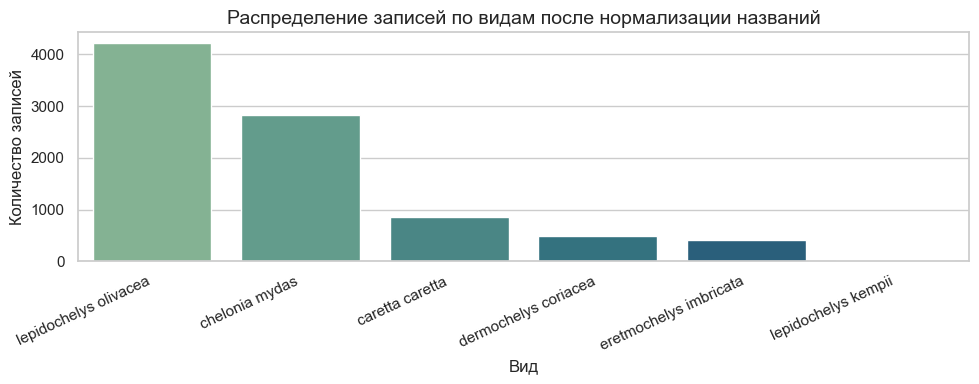

In [5]:
df_eda = df_raw.copy()
df_eda['species_norm'] = normalize_species_name(df_eda[SPECIES_COLUMN])

species_counts_raw = (
    df_eda[SPECIES_COLUMN]
    .astype('string')
    .value_counts(dropna=False)
    .rename_axis(label_feature(SPECIES_COLUMN))
    .rename('Количество')
    .to_frame()
)
species_counts_normalized = (
    df_eda['species_norm']
    .value_counts(dropna=False)
    .rename_axis(label_feature('species_norm'))
    .rename('Количество')
    .to_frame()
)
df_species = df_eda[df_eda['species_norm'] == 'chelonia mydas'].copy()

display(species_counts_raw.head(10))
display(species_counts_normalized)

species_plot = species_counts_normalized.reset_index()
species_plot = species_plot[species_plot[label_feature('species_norm')].notna()].copy()

plt.figure(figsize=(10, 4))
ax = sns.barplot(data=species_plot, x=label_feature('species_norm'), y='Количество', hue=label_feature('species_norm'), dodge=False, palette='crest')
legend = ax.get_legend()
if legend is not None:
    legend.remove()
plt.xticks(rotation=25, ha='right')
plt.title('Распределение записей по видам после нормализации названий')
plt.xlabel('Вид')
plt.ylabel('Количество записей')
plt.tight_layout()
plt.show()



**Короткий вывод:** после нормализации названий видно, что в исходном файле смешаны несколько видов и разные варианты записи одного и того же вида. Для работы оставляю только `Chelonia mydas`. После нормализации это `2829` записей. Этого достаточно для уверенного анализа и при этом не смешивает в одной модели биологически разные виды.


После отбора `Chelonia mydas` сначала разберу пропуски и дубликаты. Здесь важно не спутать технический повтор строки с реальным повторным измерением одной и той же черепахи.


In [6]:
missing_species = describe_missing_values(df_species)
missing_species_display = label_feature_index(missing_species)
duplicate_summary = pd.DataFrame({
    'metric': ['rows_before_cleaning', 'full_duplicate_rows', 'duplicate_ids', 'duplicate_registration_numbers'],
    'value': [
        len(df_species),
        int(df_species.duplicated().sum()),
        int(df_species.duplicated(subset=['id']).sum()),
        int(df_species.duplicated(subset=['registration_number']).sum()),
    ],
})
duplicate_summary_display = add_summary_label_column(duplicate_summary)
shell_crack_distribution = (
    df_species['shell_crack']
    .value_counts(dropna=False)
    .rename_axis(label_feature('shell_crack'))
    .rename('Количество')
    .to_frame()
)

display(missing_species_display)
display(duplicate_summary_display)
display(shell_crack_distribution)



,missing_count,missing_share
Трещины панциря (shell_crack),2152,0.761
Число измерений (measure_count),81,0.029
Длина головы (head_length),39,0.014
Ширина головы (head_width),39,0.014
Длина панциря (shell_length),35,0.012
Длина ласты 4 (flipper_length_4),31,0.011
Длина ласты 3 (flipper_length_3),31,0.011
Ширина ласты 4 (flipper_width_4),31,0.011
Ширина ласты 3 (flipper_width_3),31,0.011
Регистрационный номер (registration_number),4,0.001


,metric_ru,metric,value
0,Строк до очистки,rows_before_cleaning,2829
1,Полные дубли,full_duplicate_rows,341
2,Повторяющиеся идентификаторы,duplicate_ids,341
3,Повторяющиеся регистрационные номера,duplicate_registration_numbers,344


,Количество
Трещины панциря (shell_crack),
NaN,2152
1.000,440
2.000,89
3.000,67
5.000,56
4.000,25


**Короткий вывод:** у `shell_crack` пропусков очень много, около `76.1%`, поэтому заполнять этот признак заранее было бы неаккуратно. При этом видно, что реальные значения лежат в диапазоне `1-5`, а `0` в данных не встречается. Значит позже можно безопасно использовать `fillna(0)`, но только вместе с отдельным флагом пропуска. Полных дублей здесь `341`, и они же объясняют повторяющиеся `id`, так что такие строки можно убрать без сожаления. А вот повторы `registration_number` я не удаляю автоматически: это уже может быть не копия строки, а несколько наблюдений одной и той же черепахи.


Теперь смотрю на распределения ключевых признаков после очистки и отдельно проверяю, где именно проявилась ошибка с лишним умножением на `10`. Сначала фиксирую общую картину в таблицах, а потом отдельно показываю boxplot и гистограммы. Так раздел читается спокойнее, и выводы по данным не теряются между графиками.

Сначала фиксирую, какие аномалии нашлись в размерах и что осталось в данных после очистки. Эти таблицы помогают не потерять фактическую картину до перехода к графикам.

In [7]:
size_anomaly_summary = summarize_size_anomalies(df_species)
anomaly_mask = (df_species[SHELL_COLUMNS] > 2000).any(axis=1)
anomaly_examples = df_species.loc[
    anomaly_mask,
    ['id', 'registration_number', 'shell_length', 'shell_width', 'weight'],
].sort_values('shell_length')

df_model_base = fix_shell_scale_error(df_species.drop_duplicates())
df_model_base = df_model_base[df_model_base[TARGET_COLUMN].notna() & (df_model_base[TARGET_COLUMN] > 0)].copy()
df_model_base['shell_crack_missing'] = df_model_base['shell_crack'].isna().astype(int)
df_model_base['shell_crack_filled0'] = df_model_base['shell_crack'].fillna(0)
df_model_base['flipper_length_mean'] = df_model_base[FLIPPER_LENGTH_COLUMNS].mean(axis=1)
df_model_base['flipper_width_mean'] = df_model_base[FLIPPER_WIDTH_COLUMNS].mean(axis=1)
df_model_base['shell_area'] = df_model_base['shell_length'] * df_model_base['shell_width']
df_model_base['head_area'] = df_model_base['head_length'] * df_model_base['head_width']
df_model_base['flipper_area_mean'] = df_model_base['flipper_length_mean'] * df_model_base['flipper_width_mean']

cleaning_summary = pd.DataFrame({
    'metric': ['rows_after_drop_duplicates', 'rows_with_shell_x10_fix', 'rows_after_valid_target_filter', 'shell_crack_missing_share'],
    'value': [
        len(df_species.drop_duplicates()),
        int(anomaly_mask.sum()),
        len(df_model_base),
        round(df_species['shell_crack'].isna().mean(), 4),
    ],
})
cleaning_summary_display = add_summary_label_column(cleaning_summary)

distribution_columns = ['shell_length', 'shell_width', 'flipper_length_mean', 'circle_count', TARGET_COLUMN]
scale_summary = df_model_base[distribution_columns].agg(['min', 'median', 'max']).T
scale_summary_display = label_feature_index(scale_summary)
axis_labels = {column: FEATURE_AXIS_LABELS[column] for column in distribution_columns}
plot_titles = {column: FEATURE_LABELS[column] for column in distribution_columns}
size_anomaly_summary_display = add_feature_label_column(size_anomaly_summary, 'feature')
anomaly_examples_display = anomaly_examples.rename(columns={
    'id': FEATURE_LABELS['id'],
    'registration_number': FEATURE_LABELS['registration_number'],
    'shell_length': FEATURE_AXIS_LABELS['shell_length'],
    'shell_width': FEATURE_AXIS_LABELS['shell_width'],
    'weight': FEATURE_AXIS_LABELS[TARGET_COLUMN],
})

plot_columns = 2
plot_rows = (len(distribution_columns) + plot_columns - 1) // plot_columns

display(size_anomaly_summary_display)
display(anomaly_examples_display)
display(cleaning_summary_display)
display(scale_summary_display)


,feature_ru,feature,max_value,rows_gt_2000
0,Длина панциря (shell_length),shell_length,"12,840.000",10
1,Ширина панциря (shell_width),shell_width,"11,550.000",10
2,Длина ласты 1 (flipper_length_1),flipper_length_1,"1,147.000",0
3,Ширина ласты 1 (flipper_width_1),flipper_width_1,"1,072.000",0
4,Длина ласты 2 (flipper_length_2),flipper_length_2,"1,049.000",0
5,Ширина ласты 2 (flipper_width_2),flipper_width_2,997.000,0
6,Длина ласты 3 (flipper_length_3),flipper_length_3,934.000,0
7,Длина ласты 4 (flipper_length_4),flipper_length_4,877.000,0
8,Ширина ласты 3 (flipper_width_3),flipper_width_3,837.000,0
9,Ширина ласты 4 (flipper_width_4),flipper_width_4,806.000,0


,Идентификатор записи (id),Регистрационный номер (registration_number),"Длина панциря (shell_length), мм","Ширина панциря (shell_width), мм","Масса (weight), кг"
2277,20206,efa501f1195277f7e3d25e83fb0494fe,"7,340.000",6230,53.604
7164,23087,c134b99f0186e5b9bb0613bd73f75aa8,"8,750.000",7750,78.449
8183,23087,c134b99f0186e5b9bb0613bd73f75aa8,"8,750.000",7750,78.449
7345,23433,ec69e87434a551369aebec62917fc280,"9,660.000",8780,83.639
8364,23433,ec69e87434a551369aebec62917fc280,"9,660.000",8780,83.639
1132,23569,8ddad1855439e78a51e003080dc46d9b,"9,840.000",9150,95.752
2712,19720,5ed560389a5c963dd0b9efe5b1db798a,"10,080.000",8660,89.346
453,18477,995a4b32e7dd543ba81aaafe8cae8bca,"10,860.000",9710,94.922
349,17912,ffb1fdb1ed00f2edb7495bd6bd219fcc,"11,240.000",10120,110.143
165,23436,6e103cb141423f9c05256cf8acf42aaf,"12,840.000",11550,127.917


,metric_ru,metric,value
0,Строк после удаления дублей,rows_after_drop_duplicates,"2,488.000"
1,Строк с исправлением x10,rows_with_shell_x10_fix,10.000
2,Строк после фильтра по корректной массе,rows_after_valid_target_filter,"2,483.000"
3,Доля пропусков по shell_crack,shell_crack_missing_share,0.761


,min,median,max
Длина панциря (shell_length),645.000,979.500,"1,683.000"
Ширина панциря (shell_width),564.000,887.000,"1,554.000"
Средняя длина ласт (flipper_length_mean),341.500,532.250,950.000
Количество колец (circle_count),29.000,80.000,143.000
Масса (weight),49.045,87.951,199.961


Теперь отдельно показываю boxplot по ключевым признакам. Здесь удобнее всего смотреть на разброс, правые хвосты и возможные оставшиеся выбросы после исправления x10-ошибки.

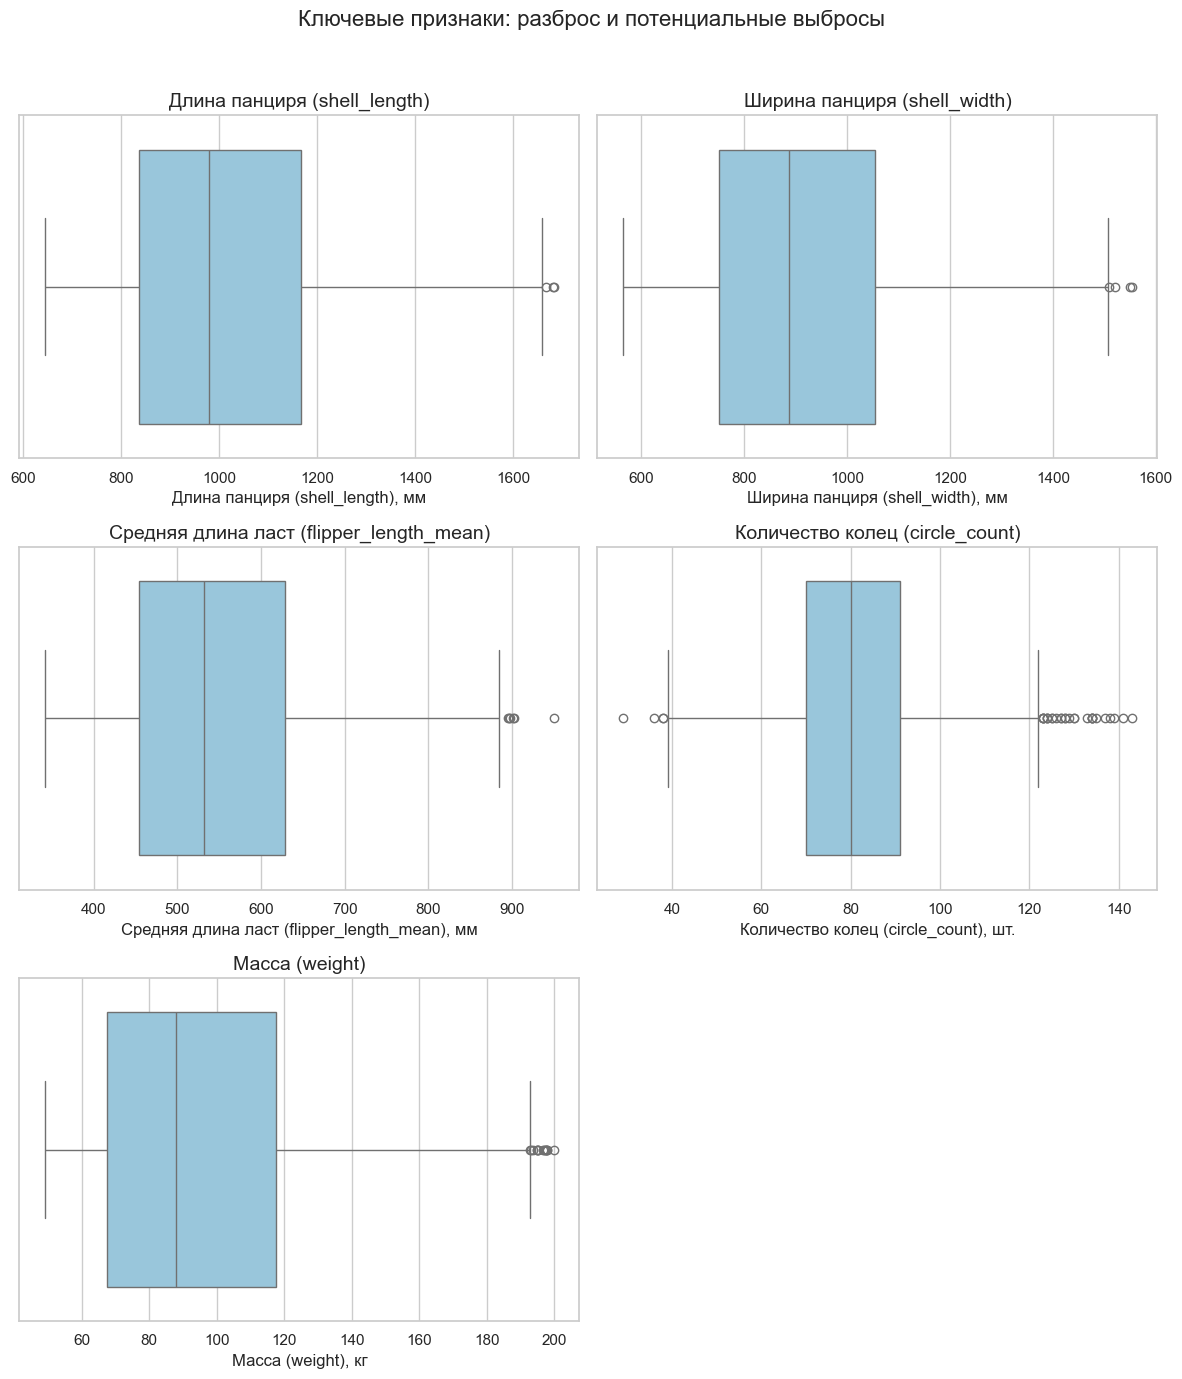

In [8]:
fig, axes = plt.subplots(plot_rows, plot_columns, figsize=(6 * plot_columns, 4.5 * plot_rows))
axes = axes.ravel() if hasattr(axes, 'ravel') else [axes]
for idx, column in enumerate(distribution_columns):
    sns.boxplot(x=df_model_base[column], ax=axes[idx], color='#8ecae6')
    axes[idx].set_title(plot_titles[column])
    axes[idx].set_xlabel(axis_labels[column])
    axes[idx].set_yticks([])

for idx in range(len(distribution_columns), len(axes)):
    axes[idx].axis('off')

fig.suptitle('Ключевые признаки: разброс и потенциальные выбросы', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


После этого смотрю на форму распределений. Гистограммы лучше показывают центр, асимметрию и различие масштабов между признаками.

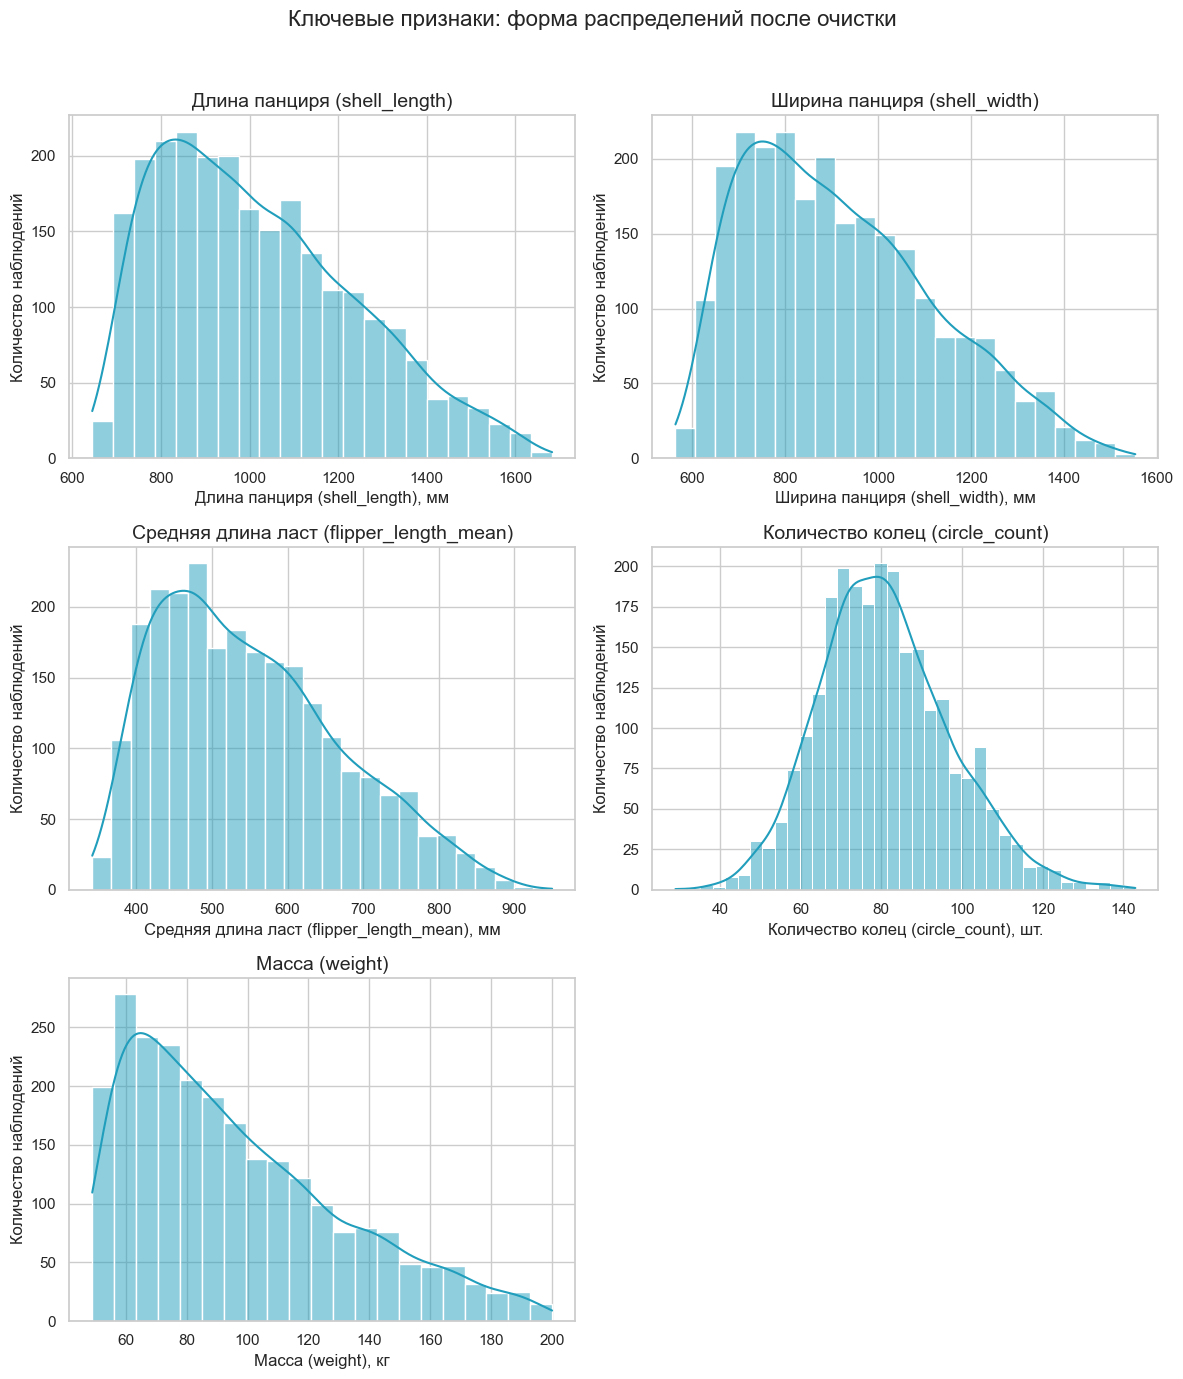

In [9]:
fig, axes = plt.subplots(plot_rows, plot_columns, figsize=(6 * plot_columns, 4.5 * plot_rows))
axes = axes.ravel() if hasattr(axes, 'ravel') else [axes]
for idx, column in enumerate(distribution_columns):
    sns.histplot(df_model_base[column].dropna(), kde=True, ax=axes[idx], color='#219ebc')
    axes[idx].set_title(plot_titles[column])
    axes[idx].set_xlabel(axis_labels[column])
    axes[idx].set_ylabel('Количество наблюдений')

for idx in range(len(distribution_columns), len(axes)):
    axes[idx].axis('off')

fig.suptitle('Ключевые признаки: форма распределений после очистки', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


**Короткий вывод:** проверка всех габаритных столбцов показывает, что ошибка с лишним умножением на `10` сидит именно в размерах панциря: порог `2000` мм пересекают только `shell_length` и `shell_width`, а размеры головы и ласт до таких значений не доходят. Значит исправлять лучше точечно, а не делить на `10` все размеры подряд.

По графикам видно, что после коррекции у длины панциря центр распределения держится примерно около `980` мм, у ширины около `887` мм, у средней длины ласт около `532` мм. Грубый отдельный хвост на уровне `7000-12000` мм исчез, и это как раз главный признак, что x10-ошибка снята правильно. При этом boxplot всё ещё показывает правые хвосты у крупных особей, но это уже выглядит как нормальная биологическая вариативность, а не как техническая поломка. Гистограммы заодно хорошо показывают, что размеры в миллиметрах, количество колец и масса в килограммах живут в разных диапазонах, так что дальше модели имеет смысл сравнивать и с масштабированием, и без него.

После удаления дублей и строк без корректного таргета остаётся `2483` наблюдения. Новые признаки вроде площади панциря (`shell_area`), площади головы (`head_area`) и средней площади ласт (`flipper_area_mean`) добавляю не ради красоты: так линейная модель видит не только отдельные длины, но и общий размер тела чуть цельнее.



Следующий шаг - посмотреть связи признаков с массой и между собой уже не только таблицей, но и на графиках. Сначала фиксирую сами коэффициенты и пары с сильной мультиколлинеарностью, а потом отдельно показываю bar chart и тепловую карту. Так раздел читается проще и без длинного прокручиваемого вывода.

Сначала показываю таблицы с коэффициентами корреляции и парами признаков, где связь особенно сильная. Это удобная опора перед графиками: видно не только общую картину, но и конкретные числа.

In [10]:
corr_columns = [
    'shell_length', 'shell_width', 'head_length', 'head_width',
    'flipper_length_1', 'flipper_width_1', 'flipper_length_2', 'flipper_width_2',
    'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4',
    'circle_count', 'measure_count', 'shell_crack_filled0', 'shell_crack_missing',
    'flipper_length_mean', 'flipper_width_mean', 'shell_area', 'head_area', 'flipper_area_mean',
    TARGET_COLUMN,
]

corr_with_target = (
    df_model_base[corr_columns]
    .corr()[TARGET_COLUMN]
    .sort_values(ascending=False)
    .rename('corr_with_weight')
    .to_frame()
)

corr_plot_df = (
    corr_with_target
    .drop(index=TARGET_COLUMN)
    .assign(abs_corr=lambda frame: frame['corr_with_weight'].abs())
    .reset_index()
    .rename(columns={'index': 'feature'})
    .sort_values('abs_corr', ascending=False)
)
corr_plot_df['feature_label'] = corr_plot_df['feature'].map(FEATURE_LABELS).fillna(corr_plot_df['feature'])
corr_with_target_display = add_feature_label_column(
    corr_with_target.reset_index().rename(columns={'index': 'feature'})
)

multicollinearity_columns = [
    'shell_length', 'shell_width', 'head_length', 'head_width',
    'flipper_length_1', 'flipper_width_1', 'flipper_length_2', 'flipper_width_2',
    'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4',
    'circle_count', 'measure_count',
]
correlation_matrix_abs = df_model_base[multicollinearity_columns].corr().abs()
upper_triangle_mask = pd.DataFrame(
    [
        [column_index > row_index for column_index in range(len(multicollinearity_columns))]
        for row_index in range(len(multicollinearity_columns))
    ],
    index=correlation_matrix_abs.index,
    columns=correlation_matrix_abs.columns,
)
upper_triangle = correlation_matrix_abs.where(upper_triangle_mask)
high_collinearity_pairs = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'corr'})
    .query('corr >= 0.9')
    .sort_values('corr', ascending=False)
)
high_collinearity_pairs_display = high_collinearity_pairs.copy()
high_collinearity_pairs_display.insert(0, 'feature_1_ru', high_collinearity_pairs_display['feature_1'].map(label_feature))
high_collinearity_pairs_display.insert(1, 'feature_2_ru', high_collinearity_pairs_display['feature_2'].map(label_feature))

correlation_heatmap_columns = [
    'shell_length', 'shell_width', 'head_length', 'head_width',
    'flipper_length_mean', 'flipper_width_mean', 'circle_count', 'measure_count',
    'shell_crack_filled0', 'shell_crack_missing', 'shell_area', 'head_area', 'flipper_area_mean',
    TARGET_COLUMN,
]
correlation_heatmap = df_model_base[correlation_heatmap_columns].corr()
correlation_heatmap_labeled = correlation_heatmap.rename(index=FEATURE_LABELS, columns=FEATURE_LABELS)

display(corr_with_target_display.head(15))
display(high_collinearity_pairs_display.head(15))


,feature_ru,feature,corr_with_weight
0,Масса (weight),weight,1.000
1,Площадь панциря (shell_area),shell_area,0.988
2,Длина панциря (shell_length),shell_length,0.984
3,Средняя площадь ласт (flipper_area_mean),flipper_area_mean,0.983
4,Средняя длина ласт (flipper_length_mean),flipper_length_mean,0.975
5,Ширина панциря (shell_width),shell_width,0.969
6,Средняя ширина ласт (flipper_width_mean),flipper_width_mean,0.967
7,Длина ласты 1 (flipper_length_1),flipper_length_1,0.927
8,Длина ласты 2 (flipper_length_2),flipper_length_2,0.924
9,Длина ласты 4 (flipper_length_4),flipper_length_4,0.924


,feature_1_ru,feature_2_ru,feature_1,feature_2,corr
1,Длина панциря (shell_length),Ширина панциря (shell_width),shell_length,shell_width,0.960
4,Длина панциря (shell_length),Длина ласты 1 (flipper_length_1),shell_length,flipper_length_1,0.920
10,Длина панциря (shell_length),Длина ласты 4 (flipper_length_4),shell_length,flipper_length_4,0.919
6,Длина панциря (shell_length),Длина ласты 2 (flipper_length_2),shell_length,flipper_length_2,0.917
8,Длина панциря (shell_length),Длина ласты 3 (flipper_length_3),shell_length,flipper_length_3,0.915
20,Ширина панциря (shell_width),Длина ласты 2 (flipper_length_2),shell_width,flipper_length_2,0.905
18,Ширина панциря (shell_width),Длина ласты 1 (flipper_length_1),shell_width,flipper_length_1,0.904
24,Ширина панциря (shell_width),Длина ласты 4 (flipper_length_4),shell_width,flipper_length_4,0.903
22,Ширина панциря (shell_width),Длина ласты 3 (flipper_length_3),shell_width,flipper_length_3,0.902


Теперь отдельно строю горизонтальный график корреляций с массой. На нём легче всего увидеть, какие признаки тянут прогноз сильнее всего и в какую сторону идёт связь.

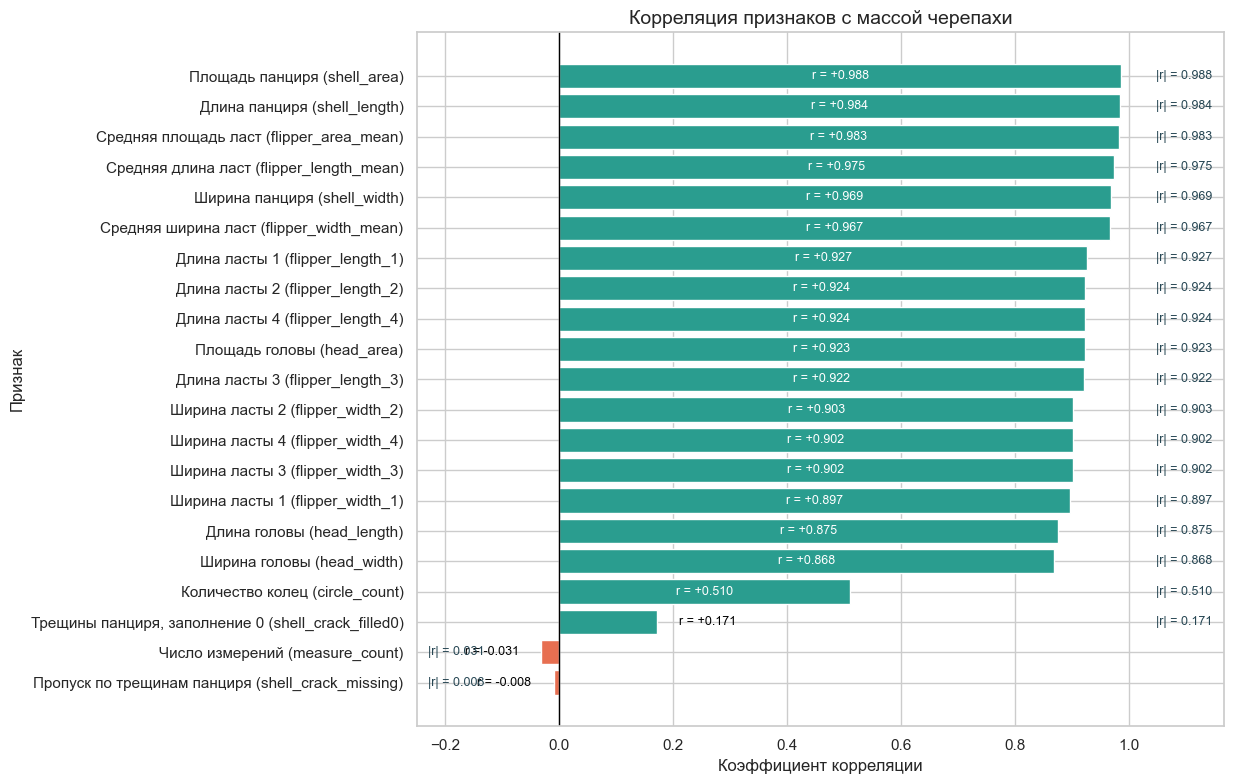

In [11]:
plt.figure(figsize=(12.5, 8))
bar_colors = ['#2a9d8f' if value >= 0 else '#e76f51' for value in corr_plot_df['corr_with_weight']]
bars = plt.barh(corr_plot_df['feature_label'], corr_plot_df['corr_with_weight'], color=bar_colors)
plt.axvline(0, color='black', linewidth=1)
plt.gca().invert_yaxis()
plt.title('Корреляция признаков с массой черепахи')
plt.xlabel('Коэффициент корреляции')
plt.ylabel('Признак')

x_min = min(corr_plot_df['corr_with_weight'].min() - 0.18, -0.25)
x_max = max(corr_plot_df['corr_with_weight'].max() + 0.18, 0.25)
plt.xlim(x_min, x_max)

inside_threshold = 0.30
bar_label_offset = 0.04
edge_padding = 0.02

for bar, value, abs_value in zip(bars, corr_plot_df['corr_with_weight'], corr_plot_df['abs_corr']):
    y_pos = bar.get_y() + bar.get_height() / 2
    side = 1 if value >= 0 else -1
    outside_x = value + side * bar_label_offset
    outside_ha = 'left' if side > 0 else 'right'

    if abs(value) >= inside_threshold:
        plt.text(value / 2, y_pos, f'r = {value:+.3f}', va='center', ha='center', color='white', fontsize=9)
    else:
        plt.text(outside_x, y_pos, f'r = {value:+.3f}', va='center', ha=outside_ha, color='black', fontsize=9)

    edge_x = x_max - edge_padding if side > 0 else x_min + edge_padding
    edge_ha = 'right' if side > 0 else 'left'
    plt.text(edge_x, y_pos, f'|r| = {abs_value:.3f}', va='center', ha=edge_ha, color='#264653', fontsize=9)

plt.tight_layout()
plt.show()


После этого оставляю тепловую карту. Она нужна уже не для ранжирования признаков по силе связи с массой, а для чтения общей структуры зависимостей внутри набора признаков.

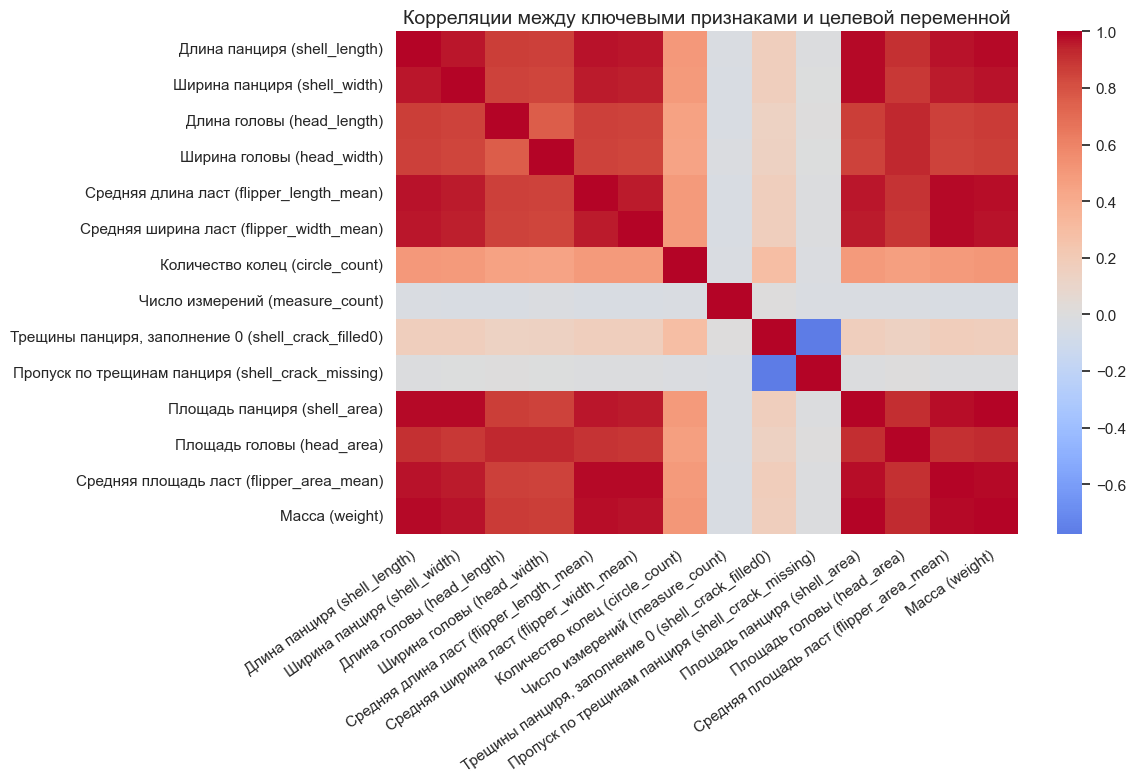

In [12]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_heatmap_labeled, cmap='coolwarm', center=0, annot=False)
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.title('Корреляции между ключевыми признаками и целевой переменной')
plt.tight_layout()
plt.show()


**Вывод по EDA:** после нормализации названий вида в рабочую выборку попало `2829` записей по `Chelonia mydas`, внутри них нашлось `341` полных дубля, а ещё `10` строк пришлось исправить из-за явного домножения размеров панциря на `10`. После очистки и удаления строк без корректного таргета осталось `2483` наблюдения.

Таблица масштабов показывает, что признаки живут в очень разных диапазонах: размеры панциря и ласт измеряются сотнями и тысячами миллиметров, `circle_count` - десятками, а целевая переменная дана в килограммах. Поэтому для части линейных моделей масштабирование здесь не опция, а обычная рабочая необходимость.

График корреляций показывает вполне ожидаемую картину: сильнее всего с массой связаны площадь панциря (`shell_area`, `r = 0.988`), длина панциря (`shell_length`, `r = 0.984`) и средняя площадь ласт (`flipper_area_mean`, `r = 0.983`). То есть модель в первую очередь ловит общий размер тела, и это хорошо совпадает со здравым смыслом. Тепловая карта добавляет важную деталь: размеры панциря, ласт и производные площади собираются в плотный кластер очень близких признаков. Например, связь `shell_length` и `shell_width` доходит до `0.960`, а `shell_length` с отдельными длинами ласт держится примерно около `0.915-0.920`. Это значит, что сигнал сильный, но часть его действительно дублируется.

Поэтому в модель я сознательно не несу все четыре длины и ширины ласт по отдельности, а заменяю их агрегатами: средней длиной ласт (`flipper_length_mean`), средней шириной ласт (`flipper_width_mean`) и средней площадью ласт (`flipper_area_mean`). Полностью убрать мультиколлинеарность здесь вряд ли получится без потери полезной информации, но самую грубую избыточность такой шаг снимает. Дальше устойчивость этого набора дополнительно проверяю через `Ridge` и `Lasso`.



## Предобработка данных

1. Разделите данные на выборки: обучающую (60%), валидационную (20%) и тестовую (20%). В реальных проектах стараются писать код предобработки так, чтобы предотвратить утечку данных. Это проще сделать, если сразу поделить данные.
2. Обработайте пропуски. При необходимости заполните их средними (медианными) значениями. Рассчитайте заполнитель только по обучающей выборке: это ещё одно правило для предотвращения утечки.
3. Напишите функцию для стандартизации признаков. Расчёт параметров масштабирования делайте только по обучающей выборке, чтобы не дать утечке ни малейшего шанса.
4. Напишите функцию для нормализации признаков.
5. Подготовьте несколько датасетов из трёх выборок каждый для дальнейшего обучения моделей с разным способом масштабирования: без масштабирования, с нормализацией, со стандартизацией.

In [13]:
excluded_features = pd.DataFrame({
    'feature': ['id', 'registration_number', 'timestamp', 'binomial_name', 'species_norm'],
    'short_reason': [
        'технический id записи',
        'id конкретной черепахи',
        'служебная дата',
        'константа после фильтрации по виду',
        'служебный столбец нормализации',
    ],
})
excluded_features_display = add_feature_label_column(excluded_features, 'feature')

basic_features = [
    'shell_length', 'shell_width', 'head_length', 'head_width',
    'flipper_length_mean', 'flipper_width_mean', 'circle_count', 'measure_count',
    'shell_crack_filled0', 'shell_crack_missing',
]
engineered_features = ['shell_area', 'head_area', 'flipper_area_mean']
feature_sets = {
    'basic_measurements': basic_features,
    'basic_plus_engineered': basic_features + engineered_features,
}
selected_features = feature_sets['basic_plus_engineered']

feature_set_summary = pd.DataFrame({
    'feature_set': list(feature_sets.keys()),
    'feature_count': [len(feature_list) for feature_list in feature_sets.values()],
    'features': [', '.join(feature_list) for feature_list in feature_sets.values()],
    'feature_labels': [label_feature_list(feature_list) for feature_list in feature_sets.values()],
})

feature_overview = pd.DataFrame({
    'feature': selected_features,
    'feature_group': ['basic' if feature in basic_features else 'engineered' for feature in selected_features],
    'dtype': [str(df_model_base[feature].dtype) for feature in selected_features],
    'missing_before_split': [int(df_model_base[feature].isna().sum()) for feature in selected_features],
})
feature_overview = add_feature_label_column(feature_overview, 'feature')

X_full = df_model_base[selected_features].copy()
X = X_full.copy()
y = df_model_base[TARGET_COLUMN].copy()

display(excluded_features_display)
display(feature_set_summary)
display(feature_overview)



,feature_ru,feature,short_reason
0,Идентификатор записи (id),id,технический id записи
1,Регистрационный номер (registration_number),registration_number,id конкретной черепахи
2,Метка времени (timestamp),timestamp,служебная дата
3,Вид в исходных данных (binomial_name),binomial_name,константа после фильтрации по виду
4,Нормализованное название вида (species_norm),species_norm,служебный столбец нормализации


,feature_set,feature_count,features,feature_labels
0,basic_measurements,10,"shell_length, shell_width, head_length, head_w...",Длина панциря (shell_length); Ширина панциря (...
1,basic_plus_engineered,13,"shell_length, shell_width, head_length, head_w...",Длина панциря (shell_length); Ширина панциря (...


,feature_ru,feature,feature_group,dtype,missing_before_split
0,Длина панциря (shell_length),shell_length,basic,float64,29
1,Ширина панциря (shell_width),shell_width,basic,int64,0
2,Длина головы (head_length),head_length,basic,float64,35
3,Ширина головы (head_width),head_width,basic,float64,35
4,Средняя длина ласт (flipper_length_mean),flipper_length_mean,basic,float64,0
5,Средняя ширина ласт (flipper_width_mean),flipper_width_mean,basic,float64,0
6,Количество колец (circle_count),circle_count,basic,int64,0
7,Число измерений (measure_count),measure_count,basic,float64,72
8,"Трещины панциря, заполнение 0 (shell_crack_fil...",shell_crack_filled0,basic,float64,0
9,Пропуск по трещинам панциря (shell_crack_missing),shell_crack_missing,basic,int64,0


**Короткий вывод:** таблицу выше я оставляю специально короткой, без длинных объяснений в коде. Причины исключения здесь довольно простые.

`id` и `registration_number` помогают отличить записи друг от друга, но не описывают размеры или форму тела. Если отдать их в модель, она получит случайные номера вместо биологического сигнала. `timestamp` тоже относится к процессу учёта, а не к свойствам черепахи. После фильтрации по одному виду `binomial_name` становится просто константой, а `species_norm` вообще нужен только как служебный шаг очистки.

Дальше я оставляю два набора признаков: базовые измерения и тот же набор плюс инженерные признаки `shell_area`, `head_area`, `flipper_area_mean`. Это удобно, потому что можно отдельно проверить, дают ли новые агрегаты реальную пользу, а не просто делают таблицу сложнее.



После EDA разделю данные на `train`, `validation` и `test`, а уже затем посчитаю медианные заполнители только по обучающей части. Так схема остаётся честной и не подмешивает статистики из валидации и теста в предобработку.



In [14]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X_full, y)
train_missing_before = X_train.isna().sum()
X_train_filled, X_val_filled, X_test_filled, train_medians = fill_with_train_median(X_train, X_val, X_test)

split_summary = pd.DataFrame({
    'dataset': ['train', 'validation', 'test'],
    'rows': [len(X_train), len(X_val), len(X_test)],
    'share': [round(len(X_train) / len(X_full), 3), round(len(X_val) / len(X_full), 3), round(len(X_test) / len(X_full), 3)],
})
split_summary_display = replace_dataset_labels(split_summary, 'dataset')
imputation_summary = pd.DataFrame({
    'feature': train_medians.index,
    'train_missing_before_fill': train_missing_before.reindex(train_medians.index).astype(int).values,
    'median_from_train': train_medians.values,
}).query('train_missing_before_fill > 0')
imputation_summary = add_feature_label_column(imputation_summary, 'feature')
remaining_missing_summary = pd.DataFrame({
    'dataset_variant': ['train_filled', 'validation_filled', 'test_filled'],
    'remaining_missing': [int(X_train_filled.isna().sum().sum()), int(X_val_filled.isna().sum().sum()), int(X_test_filled.isna().sum().sum())],
})
remaining_missing_summary_display = replace_dataset_labels(remaining_missing_summary, 'dataset_variant')

display(split_summary_display)
display(imputation_summary)
display(remaining_missing_summary_display)



,dataset,rows,share
0,train,1489,0.600
1,validation,497,0.200
2,test,497,0.200


,feature_ru,feature,train_missing_before_fill,median_from_train
0,Длина панциря (shell_length),shell_length,14,966.000
2,Длина головы (head_length),head_length,22,162.000
3,Ширина головы (head_width),head_width,22,175.000
7,Число измерений (measure_count),measure_count,46,2.000
10,Площадь панциря (shell_area),shell_area,14,"849,660.000"
11,Площадь головы (head_area),head_area,22,"28,525.000"


,dataset_variant,remaining_missing
0,train после заполнения,0
1,validation после заполнения,0
2,test после заполнения,0


**Короткий вывод:** разбиение получилось `1489/497/497`, это ровно нужная схема `60/20/20`. После заполнения медианами, которые посчитаны только по `train`, во всех трёх частях осталось `0` пропусков. То есть данные готовы к обучению, и утечка на этом шаге не появляется.



Теперь соберу три версии датасета: без масштабирования, со стандартизацией и с нормализацией. Это позволит сравнивать модели на одинаковых признаках, меняя только способ приведения масштаба.


In [15]:
feature_set_datasets = {}
scale_artifacts = {}
scaling_check_rows = []

for feature_set_name, feature_list in feature_sets.items():
    X_train_subset = X_train_filled[feature_list].copy()
    X_val_subset = X_val_filled[feature_list].copy()
    X_test_subset = X_test_filled[feature_list].copy()

    standard_artifacts = {
        'mean': X_train_subset.mean(),
        'std': X_train_subset.std().replace(0, 1),
    }
    minmax_artifacts = {
        'min': X_train_subset.min(),
        'range': (X_train_subset.max() - X_train_subset.min()).replace(0, 1),
    }

    X_train_standard, X_val_standard, X_test_standard = scale_data(X_train_subset, X_val_subset, X_test_subset, method='standard')
    X_train_minmax, X_val_minmax, X_test_minmax = scale_data(X_train_subset, X_val_subset, X_test_subset, method='minmax')

    feature_set_datasets[feature_set_name] = {
        'none': (X_train_subset.copy(), X_val_subset.copy(), X_test_subset.copy()),
        'standard': (X_train_standard, X_val_standard, X_test_standard),
        'minmax': (X_train_minmax, X_val_minmax, X_test_minmax),
    }
    scale_artifacts[feature_set_name] = {
        'none': {},
        'standard': standard_artifacts,
        'minmax': minmax_artifacts,
    }

    scaling_check_rows.append(
        pd.DataFrame({
            'feature_set': feature_set_name,
            'feature': feature_list,
            'train_mean_after_standard': X_train_standard.mean().round(3).values,
            'train_std_after_standard': X_train_standard.std().round(3).values,
            'train_min_after_minmax': X_train_minmax.min().round(3).values,
            'train_max_after_minmax': X_train_minmax.max().round(3).values,
        })
    )

scaling_check = pd.concat(scaling_check_rows, ignore_index=True)
scaling_check = add_feature_label_column(scaling_check, 'feature')

display(scaling_check.head(15))




,feature_ru,feature_set,feature,train_mean_after_standard,train_std_after_standard,train_min_after_minmax,train_max_after_minmax
0,Длина панциря (shell_length),basic_measurements,shell_length,0.000,1.000,0.000,1.000
1,Ширина панциря (shell_width),basic_measurements,shell_width,0.000,1.000,0.000,1.000
2,Длина головы (head_length),basic_measurements,head_length,0.000,1.000,0.000,1.000
3,Ширина головы (head_width),basic_measurements,head_width,0.000,1.000,0.000,1.000
4,Средняя длина ласт (flipper_length_mean),basic_measurements,flipper_length_mean,-0.000,1.000,0.000,1.000
5,Средняя ширина ласт (flipper_width_mean),basic_measurements,flipper_width_mean,0.000,1.000,0.000,1.000
6,Количество колец (circle_count),basic_measurements,circle_count,0.000,1.000,0.000,1.000
7,Число измерений (measure_count),basic_measurements,measure_count,-0.000,1.000,0.000,1.000
8,"Трещины панциря, заполнение 0 (shell_crack_fil...",basic_measurements,shell_crack_filled0,-0.000,1.000,0.000,1.000
9,Пропуск по трещинам панциря (shell_crack_missing),basic_measurements,shell_crack_missing,-0.000,1.000,0.000,1.000


**Вывод по предобработке:** в финальном наборе осталось `13` признаков, но дальше я сравниваю две его версии: только базовые измерения и базовые измерения плюс инженерные признаки. Данные уже поделены в нужной пропорции `60/20/20`, пропуски заполнены медианами только по `train`, а `scale_data` считает параметры масштаба тоже только по обучающей части. Значит схема чистая и без утечки. Для каждого набора признаков готовы три версии данных: без масштабирования, со стандартизацией и с нормализацией.



## Обучение моделей

1. Постройте базовую модель (дамми), с которой будете сравнивать все остальные. Если они будут хуже базовой по качеству, это будет означать, что при обучении что-то пошло не так. Пример дамми: модель, которая всегда предсказывает среднее значение целевой переменной из обучающей выборки.
2. Обучите несколько архитектур линейных моделей. Они могут различаться по ряду черт: набором отобранных признаков, масштабом признаков, установленными гиперпараметрами, функциями потерь. Попробуйте обучить следующие модели:
   - `LinearRegression`;
   - `Lasso` (L1-регуляризация);
   - `Ridge` (L2-регуляризация);
   - `SGDRegressor`.
   
   Обязательно попробуйте модели с разными значениями гиперпараметра `loss`.
- **Бонусное задание.** Подумайте, можно ли улучшить модели за счёт создания новых признаков: например, умножив длину ласт на ширину. Проверьте, усилится ли корреляция нового признака с целевой переменной, возрастёт ли благодаря ему качество модели.
3. Сформируйте итоговую таблицу с результатами моделей. Это удобно сделать в виде датафрейма pandas. Включите в таблицу следующие столбцы:
   - Название модели.
   - Название датасета — оно должно указывать на то, какой способ масштабирования использовался при подготовке данных.
   - Метрики качества, рассчитанные на валидационной выборке. Основная метрика — MAE, дополнительные — MSE, R², MAPE и прочие.

Ниже я собираю набор моделей для сравнения. Для `SGDRegressor` добавлен маленький совместимый слой: в разных версиях `sklearn` квадратичная функция потерь называется по-разному, но смысл эксперимента от этого не меняется.

In [16]:
def build_compatible_sgd_regressor(loss_name, **kwargs):
    try:
        return SGDRegressor(loss=loss_name, **kwargs)
    except ValueError:
        legacy_loss_map = {
            'squared_error': 'squared_loss',
        }
        compatible_loss_name = legacy_loss_map.get(loss_name, loss_name)
        return SGDRegressor(loss=compatible_loss_name, **kwargs)


model_candidates = {
    'baseline_mean': DummyRegressor(strategy='mean'),
    'baseline_median': DummyRegressor(strategy='median'),
    'linear_regression': LinearRegression(),
    'ridge_alpha_0.1': Ridge(alpha=0.1, random_state=RANDOM_STATE),
    'ridge_alpha_1': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'ridge_alpha_10': Ridge(alpha=10.0, random_state=RANDOM_STATE),
    'lasso_alpha_0.0001': Lasso(alpha=0.0001, random_state=RANDOM_STATE, max_iter=50000),
    'lasso_alpha_0.001': Lasso(alpha=0.001, random_state=RANDOM_STATE, max_iter=50000),
    'lasso_alpha_0.01': Lasso(alpha=0.01, random_state=RANDOM_STATE, max_iter=50000),
    'sgd_squared_error': build_compatible_sgd_regressor('squared_error', random_state=RANDOM_STATE, max_iter=5000, tol=1e-4),
    'sgd_epsilon_insensitive': build_compatible_sgd_regressor('epsilon_insensitive', epsilon=0.0, random_state=RANDOM_STATE, max_iter=5000, tol=1e-4),
    'sgd_huber': build_compatible_sgd_regressor('huber', epsilon=1.35, random_state=RANDOM_STATE, max_iter=5000, tol=1e-4),
}

display(
    pd.DataFrame({
        'model': list(model_candidates.keys()),
        'notes': [
            'Базовый ориентир: всегда предсказывает среднее значение train',
            'Базовый ориентир: всегда предсказывает медиану train',
            'Обычная линейная регрессия без регуляризации',
            'Ridge с мягкой L2-регуляризацией',
            'Ridge со средней L2-регуляризацией',
            'Ridge с более сильной L2-регуляризацией',
            'Lasso с очень слабой L1-регуляризацией',
            'Lasso со средней L1-регуляризацией',
            'Lasso с более сильной L1-регуляризацией',
            'SGDRegressor с квадратичной функцией потерь',
            'SGDRegressor с MAE-подобной функцией потерь',
            'SGDRegressor с функцией потерь Huber',
        ],
    })
)


,model,notes
0,baseline_mean,Базовый ориентир: всегда предсказывает среднее...
1,baseline_median,Базовый ориентир: всегда предсказывает медиану...
2,linear_regression,Обычная линейная регрессия без регуляризации
3,ridge_alpha_0.1,Ridge с мягкой L2-регуляризацией
4,ridge_alpha_1,Ridge со средней L2-регуляризацией
5,ridge_alpha_10,Ridge с более сильной L2-регуляризацией
6,lasso_alpha_0.0001,Lasso с очень слабой L1-регуляризацией
7,lasso_alpha_0.001,Lasso со средней L1-регуляризацией
8,lasso_alpha_0.01,Lasso с более сильной L1-регуляризацией
9,sgd_squared_error,SGDRegressor с квадратичной функцией потерь


Теперь запускаю единый цикл обучения по всем моделям, вариантам масштабирования и двум наборам признаков. Так видно сразу три вещи: что дают инженерные признаки, насколько чувствительны модели к масштабу и есть ли реальный эффект от регуляризации.


In [17]:
validation_rows = []
fitted_models = {}
validation_adult_mask = get_adult_mask(y_val)

for feature_set_name, scale_variants in feature_set_datasets.items():
    for scale_name, (X_train_variant, X_val_variant, X_test_variant) in scale_variants.items():
        for model_name, model in model_candidates.items():
            if model_name.startswith('baseline_') and scale_name != 'none':
                continue

            fitted_model = clone(model)
            fitted_model.fit(X_train_variant, y_train)
            fitted_models[(feature_set_name, model_name, scale_name)] = fitted_model

            train_predictions = fitted_model.predict(X_train_variant)
            val_predictions = fitted_model.predict(X_val_variant)

            train_metrics = calc_metrics(y_train, train_predictions)
            val_metrics = calc_metrics(y_val, val_predictions)
            adult_mae_val = calc_subset_mae(y_val, val_predictions, validation_adult_mask)

            validation_rows.append({
                'feature_set': feature_set_name,
                'feature_count': len(feature_sets[feature_set_name]),
                'model': model_name,
                'scale': scale_name,
                'adult_count_val_50_150kg': int(validation_adult_mask.sum()),
                'MAE_val_adult_50_150kg': adult_mae_val,
                **{f'{metric}_train': value for metric, value in train_metrics.items()},
                **{f'{metric}_val': value for metric, value in val_metrics.items()},
            })

validation_results = pd.DataFrame(validation_rows).sort_values(['MAE_val_adult_50_150kg', 'MAE_val', 'R2_val'], ascending=[True, True, False]).reset_index(drop=True)
display(validation_results)


,feature_set,feature_count,model,scale,adult_count_val_50_150kg,MAE_val_adult_50_150kg,MAE_train,MSE_train,MAPE_train,R2_train,MAE_val,MSE_val,MAPE_val,R2_val
0,basic_plus_engineered,13,lasso_alpha_0.001,standard,442,2.943,3.079,17.110,0.033,0.986,3.264,18.770,0.034,0.986
1,basic_plus_engineered,13,lasso_alpha_0.0001,minmax,442,2.943,3.080,17.108,0.033,0.986,3.265,18.769,0.034,0.986
2,basic_plus_engineered,13,ridge_alpha_0.1,standard,442,2.944,3.079,17.109,0.033,0.986,3.266,18.781,0.034,0.986
3,basic_plus_engineered,13,lasso_alpha_0.0001,standard,442,2.944,3.081,17.107,0.033,0.986,3.266,18.771,0.034,0.986
4,basic_plus_engineered,13,lasso_alpha_0.001,minmax,442,2.944,3.079,17.164,0.033,0.986,3.264,18.795,0.034,0.986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,basic_measurements,10,sgd_huber,none,442,708.252,735.115,"570,582.293",8.084,-472.503,747.295,"590,577.983",8.077,-449.532
60,basic_plus_engineered,13,sgd_epsilon_insensitive,none,442,"53,746,503.772","58,895,970.589","4,151,465,349,886,143.000","603,588.617","-3,445,130,598,551.439","60,452,064.560","4,398,024,889,086,886.500","607,015.383","-3,355,101,840,825.416"
61,basic_plus_engineered,13,sgd_huber,none,442,"72,557,749.176","79,509,526.966","7,566,039,455,020,980.000","814,844.284","-6,278,745,416,256.100","81,610,253.150","8,015,393,889,018,884.000","819,470.416","-6,114,668,168,141.052"
62,basic_measurements,10,sgd_squared_error,none,442,"573,297,883,166,367.500","596,809,272,058,331.000","375,682,632,219,428,661,699,649,994,752.000","6,579,096,968,307.412","-311,763,587,678,594,602,421,452,800.000","605,468,728,284,343.375","388,010,012,217,359,195,986,611,666,944.000","6,549,068,122,031.182","-295,999,485,923,742,254,075,215,872.000"


**Короткий вывод:** итоговая таблица готова. Её главное достоинство в том, что все модели обучены на одном и том же разбиении данных, а меняются только признаки, масштабирование и настройки самой модели. Значит дальше сравнение будет честным.



Сначала отдельно проверю, дают ли инженерные признаки реальную пользу при прочих равных. Здесь важно не спутать эффект признаков с эффектом модели, поэтому сравниваю только парные конфигурации с одинаковыми `model` и `scale`, где меняется только набор признаков.



In [18]:
paired_feature_set_comparison = (
    validation_results.loc[
        ~validation_results['model'].str.startswith('baseline_'),
        ['feature_set', 'model', 'scale', 'MAE_val_adult_50_150kg', 'MAE_val', 'MAPE_val', 'R2_val']
    ]
    .pivot_table(
        index=['model', 'scale'],
        columns='feature_set',
        values=['MAE_val_adult_50_150kg', 'MAE_val', 'MAPE_val', 'R2_val'],
    )
)
paired_feature_set_comparison.columns = [f'{metric}_{feature_set}' for metric, feature_set in paired_feature_set_comparison.columns]
paired_feature_set_comparison = paired_feature_set_comparison.reset_index()
paired_feature_set_comparison['adult_mae_gain_kg'] = (
    paired_feature_set_comparison['MAE_val_adult_50_150kg_basic_measurements']
    - paired_feature_set_comparison['MAE_val_adult_50_150kg_basic_plus_engineered']
)
paired_feature_set_comparison['adult_mae_gain_grams'] = (paired_feature_set_comparison['adult_mae_gain_kg'] * 1000).round(1)
paired_feature_set_comparison['adult_mae_gain_percent'] = (
    paired_feature_set_comparison['adult_mae_gain_kg']
    / paired_feature_set_comparison['MAE_val_adult_50_150kg_basic_measurements']
    * 100
).round(3)

stable_feature_set_pairs = paired_feature_set_comparison.query(
    'MAE_val_adult_50_150kg_basic_measurements < 10 and MAE_val_adult_50_150kg_basic_plus_engineered < 10'
).copy()
reference_pair = stable_feature_set_pairs.sort_values(
    ['MAE_val_adult_50_150kg_basic_plus_engineered', 'adult_mae_gain_kg'],
    ascending=[True, False],
).iloc[0]

feature_set_pair_summary = pd.DataFrame({
    'metric': [
        'reference_model',
        'reference_scale',
        'adult_mae_basic_measurements',
        'adult_mae_basic_plus_engineered',
        'gain_from_engineering_grams',
        'gain_from_engineering_percent',
        'engineered_better_pairs_among_stable',
        'median_gain_grams_among_stable',
    ],
    'value': [
        reference_pair['model'],
        reference_pair['scale'],
        round(reference_pair['MAE_val_adult_50_150kg_basic_measurements'], 6),
        round(reference_pair['MAE_val_adult_50_150kg_basic_plus_engineered'], 6),
        round(reference_pair['adult_mae_gain_grams'], 1),
        round(reference_pair['adult_mae_gain_percent'], 3),
        f"{int((stable_feature_set_pairs['adult_mae_gain_kg'] > 0).sum())} из {len(stable_feature_set_pairs)}",
        round((stable_feature_set_pairs['adult_mae_gain_kg'].median() * 1000), 1),
    ],
})

display(
    stable_feature_set_pairs
    .sort_values(['MAE_val_adult_50_150kg_basic_plus_engineered', 'adult_mae_gain_kg'], ascending=[True, False])
    [['model', 'scale', 'MAE_val_adult_50_150kg_basic_measurements', 'MAE_val_adult_50_150kg_basic_plus_engineered', 'adult_mae_gain_grams', 'adult_mae_gain_percent']]
    .head(12)
)
display(feature_set_pair_summary)


,model,scale,MAE_val_adult_50_150kg_basic_measurements,MAE_val_adult_50_150kg_basic_plus_engineered,adult_mae_gain_grams,adult_mae_gain_percent
5,lasso_alpha_0.001,standard,3.496,2.943,553.200,15.825
0,lasso_alpha_0.0001,minmax,3.496,2.943,552.600,15.806
14,ridge_alpha_0.1,standard,3.496,2.944,552.100,15.794
2,lasso_alpha_0.0001,standard,3.496,2.944,551.800,15.783
3,lasso_alpha_0.001,minmax,3.495,2.944,551.000,15.765
9,linear_regression,minmax,3.496,2.944,551.600,15.780
11,linear_regression,standard,3.496,2.944,551.600,15.780
10,linear_regression,none,3.496,2.944,551.600,15.780
13,ridge_alpha_0.1,none,3.496,2.944,551.600,15.780
1,lasso_alpha_0.0001,none,3.496,2.944,551.600,15.779


,metric,value
0,reference_model,lasso_alpha_0.001
1,reference_scale,standard
2,adult_mae_basic_measurements,3.496
3,adult_mae_basic_plus_engineered,2.943
4,gain_from_engineering_grams,553.200
5,gain_from_engineering_percent,15.825
6,engineered_better_pairs_among_stable,27 из 27
7,median_gain_grams_among_stable,548.500


**Промежуточный вывод по наборам признаков:** здесь уже можно говорить о честной абляции, потому что модель и масштаб остаются теми же, меняется только состав признаков. На опорной конфигурации `Lasso(alpha=0.001)` со стандартизацией `adult MAE` снижается с `3.496` до `2.943` кг. Это выигрыш примерно `553` грамма, или `15.8%`, и такой выигрыш уже можно связывать именно с инженерными признаками.

Есть и более общий сигнал: среди `27` стабильных парных конфигураций расширенный набор оказался лучше во всех `27` случаях, а медианный выигрыш составил около `549` граммов. То есть `shell_area`, `head_area` и `flipper_area_mean` здесь не просто дублируют базовые размеры, а действительно добавляют модели полезную информацию.



Теперь отдельно вынесу результаты `SGDRegressor` с разными значениями `loss`, чтобы сравнение функций потерь осталось читаемым и не потерялось внутри общей таблицы.



In [19]:
sgd_loss_results = (
    validation_results.loc[
        validation_results['model'].str.startswith('sgd_'),
        ['feature_set', 'model', 'scale', 'adult_count_val_50_150kg', 'MAE_val_adult_50_150kg', 'MAE_val', 'MSE_val', 'MAPE_val', 'R2_val']
    ]
    .assign(loss=lambda df: df['model'].str.replace('sgd_', '', regex=False))
    [['feature_set', 'model', 'loss', 'scale', 'adult_count_val_50_150kg', 'MAE_val_adult_50_150kg', 'MAE_val', 'MSE_val', 'MAPE_val', 'R2_val']]
    .sort_values(['MAE_val_adult_50_150kg', 'MAE_val', 'R2_val'], ascending=[True, True, False])
    .reset_index(drop=True)
)

display(sgd_loss_results)


,feature_set,model,loss,scale,adult_count_val_50_150kg,MAE_val_adult_50_150kg,MAE_val,MSE_val,MAPE_val,R2_val
0,basic_plus_engineered,sgd_huber,huber,standard,442,3.044,3.351,21.874,0.035,0.983
1,basic_plus_engineered,sgd_epsilon_insensitive,epsilon_insensitive,standard,442,3.058,3.374,21.854,0.035,0.983
2,basic_plus_engineered,sgd_squared_error,squared_error,standard,442,3.094,3.367,19.865,0.036,0.985
3,basic_plus_engineered,sgd_huber,huber,minmax,442,3.167,3.531,22.613,0.037,0.983
4,basic_plus_engineered,sgd_epsilon_insensitive,epsilon_insensitive,minmax,442,3.177,3.558,23.017,0.037,0.982
5,basic_plus_engineered,sgd_squared_error,squared_error,minmax,442,3.241,3.526,21.605,0.038,0.984
6,basic_measurements,sgd_epsilon_insensitive,epsilon_insensitive,standard,442,3.312,3.892,27.523,0.041,0.979
7,basic_measurements,sgd_huber,huber,standard,442,3.326,3.878,27.228,0.041,0.979
8,basic_measurements,sgd_huber,huber,minmax,442,3.381,3.958,27.974,0.041,0.979
9,basic_measurements,sgd_epsilon_insensitive,epsilon_insensitive,minmax,442,3.424,4.007,28.856,0.042,0.978


**Промежуточный вывод по `SGDRegressor`:** внутри этого семейства лучший результат даёт `sgd_huber` со стандартизацией и полным набором признаков. На взрослых черепахах он опускает `MAE` до `3.044` кг. Это уже неплохо, но всё равно чуть слабее лучшей `Lasso`.

Тут хорошо видно две вещи. Во-первых, инженерные признаки помогают и для `SGDRegressor`: на наборе только с базовыми измерениями лучший результат около `3.312` кг, а на расширенном наборе заметно лучше. Во-вторых, масштабирование для `SGDRegressor` не просто полезно, а критично. Без него метрики уезжают очень далеко, и модель перестаёт быть рабочей.



## Сравнение моделей на валидационной выборке

1. Сравните построенные модели по метрикам на валидационной выборке. Удалось ли существенно улучшить результат базовой модели?
2. Выберите лучшую модель по основной метрике на валидационной выборке. Не заглядывайте в метрики на тестовой выборке раньше времени. Тестовая выборка не используется для обучения моделей, подбора гиперпараметров и сравнения моделей с разными значениями.
3. Напишите выводы о том, какая из моделей обладает лучшим качеством. Именно её одну далее нужно проверить на тестовой выборке для итоговой оценки.

,feature_set,model,scale,adult_count_val_50_150kg,MAE_val_adult_50_150kg,delta_to_best_grams,delta_to_best_percent,MAE_val,MAPE_val,R2_val
0,basic_plus_engineered,lasso_alpha_0.001,standard,442,2.943,0.000,0.000,3.264,0.034,0.986
1,basic_plus_engineered,lasso_alpha_0.0001,minmax,442,2.943,0.700,0.024,3.265,0.034,0.986
2,basic_plus_engineered,ridge_alpha_0.1,standard,442,2.944,1.000,0.035,3.266,0.034,0.986
3,basic_plus_engineered,lasso_alpha_0.0001,standard,442,2.944,1.500,0.049,3.266,0.034,0.986
4,basic_plus_engineered,lasso_alpha_0.001,minmax,442,2.944,1.500,0.051,3.264,0.034,0.986
5,basic_plus_engineered,linear_regression,minmax,442,2.944,1.600,0.054,3.266,0.034,0.986
6,basic_plus_engineered,linear_regression,standard,442,2.944,1.600,0.054,3.266,0.034,0.986
7,basic_plus_engineered,linear_regression,none,442,2.944,1.600,0.054,3.266,0.034,0.986
8,basic_plus_engineered,ridge_alpha_0.1,none,442,2.944,1.600,0.054,3.266,0.034,0.986
9,basic_plus_engineered,lasso_alpha_0.0001,none,442,2.944,1.600,0.055,3.266,0.034,0.986


,metric,value
0,best_feature_set,basic_plus_engineered
1,best_model,lasso_alpha_0.001
2,best_scale,standard
3,adult_count_val_50_150kg,442
4,MAE_val_adult_50_150kg,2.943
5,MAE_val,3.264
6,MAPE_val,0.034
7,R2_val,0.986


,model,MAE_val_adult_50_150kg,MAE_val,MAPE_val,R2_val,adult_mae_ratio_to_best,overall_mae_ratio_to_best
54,baseline_median,22.222,28.884,0.292,-0.078,7.550,8.850
56,baseline_mean,23.729,29.353,0.324,-0.003,8.060,8.990


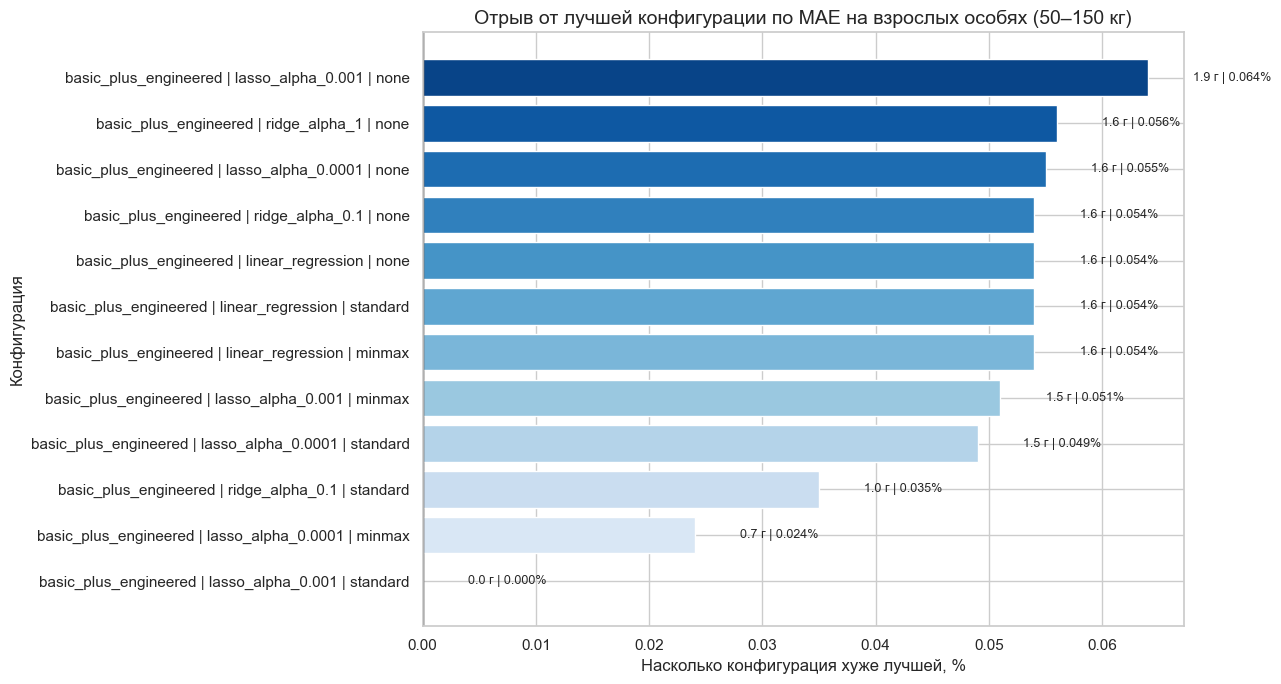

In [20]:
top_validation_results = validation_results[['feature_set', 'feature_count', 'model', 'scale', 'adult_count_val_50_150kg', 'MAE_val_adult_50_150kg', 'MAE_val', 'MAPE_val', 'R2_val']].head(12).copy()

best_row = validation_results.iloc[0]
best_feature_set_name = best_row['feature_set']
best_model_name = best_row['model']
best_scale_name = best_row['scale']
best_model = fitted_models[(best_feature_set_name, best_model_name, best_scale_name)]
best_feature_list = feature_sets[best_feature_set_name]
best_X_train, best_X_val, best_X_test = feature_set_datasets[best_feature_set_name][best_scale_name]

best_model_summary = pd.DataFrame({
    'metric': ['best_feature_set', 'best_model', 'best_scale', 'adult_count_val_50_150kg', 'MAE_val_adult_50_150kg', 'MAE_val', 'MAPE_val', 'R2_val'],
    'value': [best_feature_set_name, best_model_name, best_scale_name, int(best_row['adult_count_val_50_150kg']), round(best_row['MAE_val_adult_50_150kg'], 6), round(best_row['MAE_val'], 6), round(best_row['MAPE_val'], 6), round(best_row['R2_val'], 6)],
})

baseline_comparison = validation_results.loc[
    validation_results['model'].isin(['baseline_mean', 'baseline_median']),
    ['model', 'MAE_val_adult_50_150kg', 'MAE_val', 'MAPE_val', 'R2_val']
].drop_duplicates().copy()
baseline_comparison['adult_mae_ratio_to_best'] = (baseline_comparison['MAE_val_adult_50_150kg'] / best_row['MAE_val_adult_50_150kg']).round(2)
baseline_comparison['overall_mae_ratio_to_best'] = (baseline_comparison['MAE_val'] / best_row['MAE_val']).round(2)

top_validation_results['config'] = top_validation_results['feature_set'] + ' | ' + top_validation_results['model'] + ' | ' + top_validation_results['scale']
top_validation_results['delta_to_best_grams'] = ((top_validation_results['MAE_val_adult_50_150kg'] - best_row['MAE_val_adult_50_150kg']) * 1000).round(1)
top_validation_results['delta_to_best_percent'] = (((top_validation_results['MAE_val_adult_50_150kg'] - best_row['MAE_val_adult_50_150kg']) / best_row['MAE_val_adult_50_150kg']) * 100).round(3)
top_validation_results['MAE_val_adult_50_150kg'] = top_validation_results['MAE_val_adult_50_150kg'].round(4)
top_validation_results['MAE_val'] = top_validation_results['MAE_val'].round(4)
top_validation_results['MAPE_val'] = top_validation_results['MAPE_val'].round(4)
top_validation_results['R2_val'] = top_validation_results['R2_val'].round(4)

display(top_validation_results[['feature_set', 'model', 'scale', 'adult_count_val_50_150kg', 'MAE_val_adult_50_150kg', 'delta_to_best_grams', 'delta_to_best_percent', 'MAE_val', 'MAPE_val', 'R2_val']])
display(best_model_summary)
display(baseline_comparison)

plot_df = top_validation_results.sort_values('delta_to_best_percent', ascending=True).copy()
plt.figure(figsize=(13, 7))
bars = plt.barh(plot_df['config'], plot_df['delta_to_best_percent'], color=sns.color_palette('Blues', n_colors=len(plot_df)))
plt.axvline(0, color='black', linewidth=1)
plt.title('Отрыв от лучшей конфигурации по MAE на взрослых особях (50–150 кг)')
plt.xlabel('Насколько конфигурация хуже лучшей, %')
plt.ylabel('Конфигурация')

label_shift = max(plot_df['delta_to_best_percent'].max() * 0.006, 0.004)
for bar, grams, percent in zip(bars, plot_df['delta_to_best_grams'], plot_df['delta_to_best_percent']):
    plt.text(bar.get_width() + label_shift, bar.get_y() + bar.get_height() / 2, f'{grams:.1f} г | {percent:.3f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()


**Промежуточный вывод по сравнению моделей:** базовые модели остаются очень далеко от рабочего качества. Даже лучшая базовая модель с медианным прогнозом `DummyRegressor(median)` ошибается примерно на `22.22` кг на взрослом диапазоне и на `28.88` кг в среднем по валидационной выборке. На таком фоне преимущество нормальных линейных моделей видно сразу.

Лучшая конфигурация по главному практическому критерию - `Lasso(alpha=0.001)` на стандартизованных признаках и с расширенным набором признаков (`basic_plus_engineered`). На подвыборке `50-150` кг она даёт `MAE = 2.943` кг при `442` объектах, а общий `MAE` на валидационной выборке равен `3.264` кг.

График рядом специально показывает только верхнюю группу сильных моделей. Если смотреть на сами бары, видно главное: они почти прилипают к нулю. Первые конфигурации отличаются друг от друга буквально на `0.7-1.9` грамма, то есть меньше чем на `0.1%`. Это уже не история про то, что одна архитектура резко лучше другой. Скорее здесь видно, что после хорошей чистки данных и удачных признаков `Lasso`, `Ridge` и `LinearRegression` выходят почти на одну и ту же точность.

Эффект инженерных признаков я здесь трактую только по честной парной абляции: для одной и той же `Lasso(alpha=0.001)` со стандартизацией они снижают `adult MAE` с `3.496` до `2.943` кг, то есть на `553` грамма, или `15.8%`. Поэтому выбор `Lasso` в итоге выглядит прагматично: она первая в таблице, качество у неё очень высокое, а мягкая регуляризация добавляет немного устойчивости. Именно эту модель дальше и имеет смысл нести на тестовую выборку.



## Проверка лучшей модели на тестовой выборке

1. Проверьте метрики лучшей модели на тестовой выборке.
2. Узнайте, есть ли признаки переобучения лучшей модели.
3. Определите, соответствует ли модель требованиям заказчика. Объясните, можно ли её рекомендовать к внедрению.

In [21]:
train_predictions_best = best_model.predict(best_X_train)
val_predictions_best = best_model.predict(best_X_val)
test_predictions_best = best_model.predict(best_X_test)

validation_adult_mask = get_adult_mask(y_val)
test_adult_mask = get_adult_mask(y_test)

stage_metrics = pd.DataFrame([
    {'dataset': 'train', **calc_metrics(y_train, train_predictions_best)},
    {'dataset': 'validation', **calc_metrics(y_val, val_predictions_best)},
    {'dataset': 'test', **calc_metrics(y_test, test_predictions_best)},
])
stage_metrics_display = replace_dataset_labels(stage_metrics, 'dataset')

adult_stage_metrics = pd.DataFrame([
    {
        'dataset': 'validation_adult_50_150kg',
        'adult_count': int(validation_adult_mask.sum()),
        'MAE': calc_subset_mae(y_val, val_predictions_best, validation_adult_mask),
    },
    {
        'dataset': 'test_adult_50_150kg',
        'adult_count': int(test_adult_mask.sum()),
        'MAE': calc_subset_mae(y_test, test_predictions_best, test_adult_mask),
    },
])
adult_stage_metrics_display = replace_dataset_labels(adult_stage_metrics, 'dataset')

customer_check = pd.DataFrame({
    'criterion': [
        'MAE <= 5 на взрослых черепахах 50-150 кг в validation',
        'MAE <= 5 на взрослых черепахах 50-150 кг в test',
        'R2 >= 0.97 на validation',
        'R2 >= 0.97 на test',
    ],
    'passed': [
        bool(adult_stage_metrics.loc[adult_stage_metrics['dataset'] == 'validation_adult_50_150kg', 'MAE'].iloc[0] <= 5),
        bool(adult_stage_metrics.loc[adult_stage_metrics['dataset'] == 'test_adult_50_150kg', 'MAE'].iloc[0] <= 5),
        bool(stage_metrics.loc[stage_metrics['dataset'] == 'validation', 'R2'].iloc[0] >= 0.97),
        bool(stage_metrics.loc[stage_metrics['dataset'] == 'test', 'R2'].iloc[0] >= 0.97),
    ],
})

display(stage_metrics_display)
display(adult_stage_metrics_display)
display(customer_check)



,dataset,MAE,MSE,MAPE,R2
0,train,3.079,17.110,0.033,0.986
1,validation,3.264,18.770,0.034,0.986
2,test,3.271,19.104,0.033,0.984


,dataset,adult_count,MAE
0,"validation, взрослые 50-150 кг",442,2.943
1,"test, взрослые 50-150 кг",447,2.923


,criterion,passed
0,MAE <= 5 на взрослых черепахах 50-150 кг в val...,True
1,MAE <= 5 на взрослых черепахах 50-150 кг в test,True
2,R2 >= 0.97 на validation,True
3,R2 >= 0.97 на test,True


**Вывод по тестовой проверке:** на `train` модель даёт `MAE = 3.079` кг, на `validation` `3.264` кг, на `test` `3.271` кг. Эти числа стоят очень близко друг к другу, так что явного провала на новых данных нет.

Для взрослых особей в диапазоне `50-150` кг картина даже лучше: `MAE = 2.943` кг на `validation` (`442` наблюдения) и `2.923` кг на `test` (`447` наблюдений). Это заметно ниже рабочего порога `5` кг. По `R²` всё тоже спокойно: `0.986` на валидации и `0.984` на тесте, оба значения уверенно выше порога `0.97`. В сумме это выглядит как стабильная рабочая модель без заметного переобучения.



## Оценка важности признаков

1. Оцените важность признаков по абсолютным значениям весов лучшей модели.
2. Напишите, какие признаки стали для модели более важными. Объясните, согласны ли вы с таким результатом?

Теперь посмотрю на коэффициенты лучшей модели. Так как победила линейная модель на стандартизованных данных, абсолютные значения коэффициентов можно сравнивать между собой. Но читать этот блок всё равно нужно спокойно: из-за сильной связи между признаками размера коэффициенты здесь показывают вклад признаков внутри конкретной формулы, а не окончательную биологическую истину.



,feature_ru,feature,coefficient,abs_coefficient
12,Средняя площадь ласт (flipper_area_mean),flipper_area_mean,21.465,21.465
0,Длина панциря (shell_length),shell_length,16.630,16.630
1,Ширина панциря (shell_width),shell_width,11.979,11.979
10,Площадь панциря (shell_area),shell_area,-8.945,8.945
11,Площадь головы (head_area),head_area,8.755,8.755
5,Средняя ширина ласт (flipper_width_mean),flipper_width_mean,-6.291,6.291
3,Ширина головы (head_width),head_width,-3.177,3.177
2,Длина головы (head_length),head_length,-2.994,2.994
4,Средняя длина ласт (flipper_length_mean),flipper_length_mean,-2.797,2.797
6,Количество колец (circle_count),circle_count,0.421,0.421


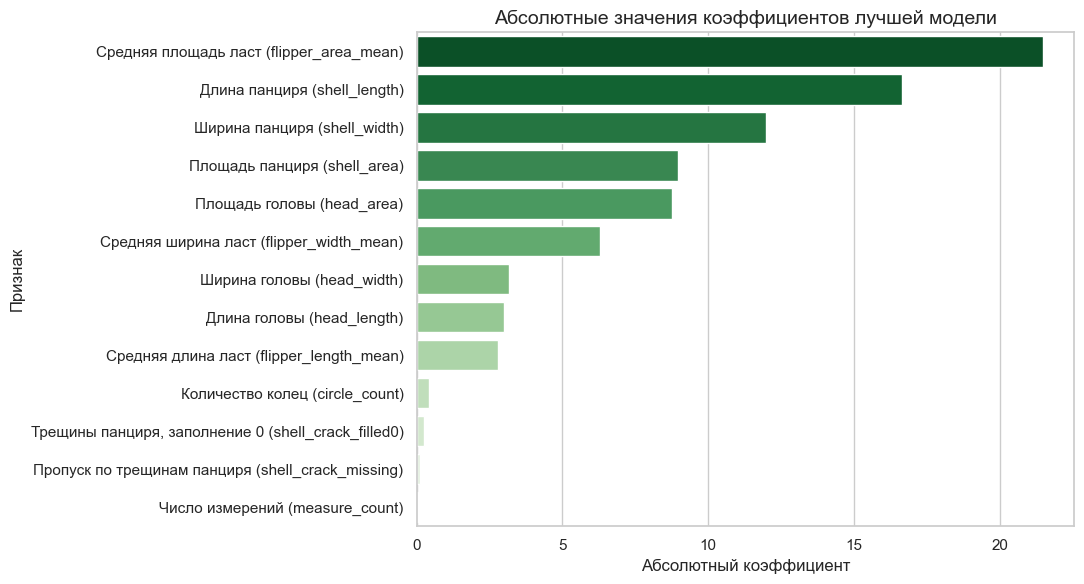

In [22]:
feature_importance_df = pd.DataFrame({
    'feature': best_feature_list,
    'coefficient': best_model.coef_,
    'abs_coefficient': abs(best_model.coef_),
}).sort_values('abs_coefficient', ascending=False)
feature_importance_df = add_feature_label_column(feature_importance_df, 'feature', 'feature_label')

feature_importance_display = feature_importance_df[[
    'feature_label', 'feature', 'coefficient', 'abs_coefficient'
]].rename(columns={'feature_label': 'feature_ru'})

display(feature_importance_display)

plt.figure(figsize=(11, 6))
sns.barplot(data=feature_importance_df, x='abs_coefficient', y='feature_label', palette='Greens_r')
plt.title('Абсолютные значения коэффициентов лучшей модели')
plt.xlabel('Абсолютный коэффициент')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()



**Вывод по важности признаков:** сильнее всего прогноз двигают средняя площадь ласт (`flipper_area_mean`), длина панциря (`shell_length`), ширина панциря (`shell_width`), площадь головы (`head_area`) и площадь панциря (`shell_area`). Это выглядит вполне здраво: масса черепахи в первую очередь должна следовать за общими габаритами тела.

Но этот рейтинг не стоит читать слишком буквально. Из-за близких описаний одного и того же размера внутри топ-5 возможны перестановки местами. Например, длина панциря (`shell_length`) и площадь панциря (`shell_area`) в соседней, почти равной по качеству модели могут поменяться порядком. Поэтому надёжный вывод здесь не в том, что один конкретный размер "самый главный", а в том, что модель в целом опирается на размеры тела. Количество колец (`circle_count`) добавляет умеренный сигнал, а число измерений (`measure_count`) и признаки, связанные с пропусками по трещинам панциря, заметно слабее.



## Функция для прогнозирования веса черепахи

* Напишите на Python функцию, которая будет прогнозировать массу черепахи по заданным параметрам с учётом коэффициентов лучшей модели (свойство `coef_`) и смещения (свойство `intercept_`).
* Если вы столкнётесь с трудностями при написании функции, то представьте, что обращаетесь к старшему коллеге с просьбой помочь, и составьте задание для её написания. Подробно опишите логику, по которой рассчитывается масса черепахи, и укажите, как именно должны происходить расчёты.

Чтобы функция считала вес корректно, она должна повторить тот же путь, который проходили данные при обучении модели.

1. На вход функция получает сырые измерения черепахи.
2. Сначала она приводит их к тем же правилам очистки, которые использовались в проекте. Самое важное место здесь - проверка x10-ошибки для длины и ширины панциря.
3. После этого из исходных измерений строятся рабочие признаки модели: признак пропуска `shell_crack`, средние размеры ласт и площади `shell_area`, `head_area`, `flipper_area_mean`.
4. Если каких-то необязательных значений нет, функция подставляет те же медианы, которые были посчитаны по обучающей выборке.
5. Дальше признаки переводятся в тот же масштаб, в котором обучалась лучшая модель.
6. И только на последнем шаге считается прогноз по формуле линейной регрессии: `prediction = intercept + sum(coef_i * x_i)`.

Смысл этого алгоритма в том, что коэффициенты модели сами по себе ничего не значат без такой же подготовки данных. Если пропустить очистку, генерацию признаков или масштабирование, формула начнёт работать уже не с теми данными, на которых модель училась, и ответу нельзя будет доверять.



In [23]:
def prepare_features_for_prediction(
    shell_length,
    shell_width,
    head_length,
    head_width,
    flipper_length_1,
    flipper_width_1,
    flipper_length_2,
    flipper_width_2,
    flipper_length_3,
    flipper_width_3,
    flipper_length_4,
    flipper_width_4,
    circle_count,
    measure_count=None,
    shell_crack=None,
):
    raw_row = pd.DataFrame([{
        'shell_length': shell_length,
        'shell_width': shell_width,
        'head_length': head_length,
        'head_width': head_width,
        'flipper_length_1': flipper_length_1,
        'flipper_width_1': flipper_width_1,
        'flipper_length_2': flipper_length_2,
        'flipper_width_2': flipper_width_2,
        'flipper_length_3': flipper_length_3,
        'flipper_width_3': flipper_width_3,
        'flipper_length_4': flipper_length_4,
        'flipper_width_4': flipper_width_4,
        'circle_count': circle_count,
        'measure_count': measure_count,
        'shell_crack': shell_crack,
    }])

    # На вход функция получает сырые измерения и сразу приводит их к тем же правилам,
    # по которым готовились обучающие данные.
    prepared = fix_shell_scale_error(raw_row)
    prepared['shell_crack_missing'] = prepared['shell_crack'].isna().astype(int)
    prepared['shell_crack_filled0'] = prepared['shell_crack'].fillna(0)
    prepared['flipper_length_mean'] = prepared[FLIPPER_LENGTH_COLUMNS].mean(axis=1)
    prepared['flipper_width_mean'] = prepared[FLIPPER_WIDTH_COLUMNS].mean(axis=1)
    prepared['shell_area'] = prepared['shell_length'] * prepared['shell_width']
    prepared['head_area'] = prepared['head_length'] * prepared['head_width']
    prepared['flipper_area_mean'] = prepared['flipper_length_mean'] * prepared['flipper_width_mean']
    prepared = prepared[best_feature_list]
    prepared = prepared.fillna(train_medians.reindex(best_feature_list))

    if best_scale_name == 'standard':
        prepared = (prepared - scale_artifacts[best_feature_set_name]['standard']['mean']) / scale_artifacts[best_feature_set_name]['standard']['std']
    elif best_scale_name == 'minmax':
        prepared = (prepared - scale_artifacts[best_feature_set_name]['minmax']['min']) / scale_artifacts[best_feature_set_name]['minmax']['range']

    return prepared


def predict_turtle_weight(**kwargs) -> float:
    prepared_features = prepare_features_for_prediction(**kwargs)
    linear_part = prepared_features.to_numpy()[0] @ best_model.coef_
    return float(best_model.intercept_ + linear_part)



Сначала разберу один реальный пример из выборки. На нём проще всего показать, как функция шаг за шагом превращает исходные измерения в итоговый прогноз массы.



In [24]:
example_index = X_train.index[0]
example_row = df_model_base.loc[example_index]
clean_kwargs = {
    'shell_length': example_row['shell_length'],
    'shell_width': example_row['shell_width'],
    'head_length': example_row['head_length'],
    'head_width': example_row['head_width'],
    'flipper_length_1': example_row['flipper_length_1'],
    'flipper_width_1': example_row['flipper_width_1'],
    'flipper_length_2': example_row['flipper_length_2'],
    'flipper_width_2': example_row['flipper_width_2'],
    'flipper_length_3': example_row['flipper_length_3'],
    'flipper_width_3': example_row['flipper_width_3'],
    'flipper_length_4': example_row['flipper_length_4'],
    'flipper_width_4': example_row['flipper_width_4'],
    'circle_count': example_row['circle_count'],
    'measure_count': example_row['measure_count'],
    'shell_crack': example_row['shell_crack'],
}
x10_kwargs = clean_kwargs.copy()
x10_kwargs['shell_length'] = clean_kwargs['shell_length'] * 10
x10_kwargs['shell_width'] = clean_kwargs['shell_width'] * 10

missing_optional_kwargs = clean_kwargs.copy()
missing_optional_kwargs['measure_count'] = float('nan')
missing_optional_kwargs['shell_crack'] = float('nan')

raw_example = pd.DataFrame([clean_kwargs])
corrected_example = fix_shell_scale_error(raw_example)
prepared_example = prepare_features_for_prediction(**clean_kwargs)
prediction_via_formula = predict_turtle_weight(**clean_kwargs)
prediction_direct_from_model = float(best_model.predict(prepared_example)[0])

pipeline_view = pd.DataFrame({
    'step': [
        'raw_shell_length_mm',
        'corrected_shell_length_mm',
        'raw_shell_width_mm',
        'corrected_shell_width_mm',
        'flipper_length_mean_mm',
        'flipper_width_mean_mm',
        'shell_area_mm2',
        'head_area_mm2',
        'flipper_area_mean_mm2',
    ],
    'value': [
        raw_example.loc[0, 'shell_length'],
        corrected_example.loc[0, 'shell_length'],
        raw_example.loc[0, 'shell_width'],
        corrected_example.loc[0, 'shell_width'],
        raw_example[FLIPPER_LENGTH_COLUMNS].mean(axis=1).iloc[0],
        raw_example[FLIPPER_WIDTH_COLUMNS].mean(axis=1).iloc[0],
        corrected_example.loc[0, 'shell_length'] * corrected_example.loc[0, 'shell_width'],
        raw_example.loc[0, 'head_length'] * raw_example.loc[0, 'head_width'],
        raw_example[FLIPPER_LENGTH_COLUMNS].mean(axis=1).iloc[0] * raw_example[FLIPPER_WIDTH_COLUMNS].mean(axis=1).iloc[0],
    ],
})

contribution_df = pd.DataFrame({
    'feature': best_feature_list,
    'prepared_value': prepared_example.iloc[0].values,
    'coefficient': best_model.coef_,
})
contribution_df['contribution_to_prediction'] = contribution_df['prepared_value'] * contribution_df['coefficient']
contribution_df = contribution_df.sort_values('contribution_to_prediction', key=abs, ascending=False)
contribution_df = add_feature_label_column(contribution_df, 'feature', 'feature_label')
contribution_display = contribution_df[[
    'feature_label', 'feature', 'prepared_value', 'coefficient', 'contribution_to_prediction'
]].rename(columns={'feature_label': 'feature_ru'})

formula_breakdown = pd.DataFrame({
    'component': ['intercept', 'sum_feature_contributions', 'prediction_via_formula', 'prediction_direct_from_model', 'actual_weight'],
    'value': [
        round(float(best_model.intercept_), 6),
        round(float(contribution_df['contribution_to_prediction'].sum()), 6),
        round(prediction_via_formula, 6),
        round(prediction_direct_from_model, 6),
        round(float(example_row['weight']), 6),
    ],
})

function_checks = []
for case_name, kwargs in [
    ('clean_train_row', clean_kwargs),
    ('same_row_with_shell_x10_error', x10_kwargs),
    ('same_row_with_missing_optional_fields', missing_optional_kwargs),
]:
    prediction_formula = predict_turtle_weight(**kwargs)
    prepared_features = prepare_features_for_prediction(**kwargs)
    prediction_model = float(best_model.predict(prepared_features)[0])
    function_checks.append({
        'case': case_name,
        'prediction_via_formula': round(prediction_formula, 6),
        'prediction_direct_from_model': round(prediction_model, 6),
        'difference': round(prediction_formula - prediction_model, 10),
    })

function_checks = pd.DataFrame(function_checks)
function_checks['difference_to_clean_case'] = (
    function_checks['prediction_via_formula']
    - function_checks.loc[function_checks['case'] == 'clean_train_row', 'prediction_via_formula'].iloc[0]
).round(6)

display(pipeline_view)
display(contribution_display.head(8))
display(formula_breakdown)
display(function_checks)



,step,value
0,raw_shell_length_mm,"1,260.000"
1,corrected_shell_length_mm,"1,260.000"
2,raw_shell_width_mm,"1,193.000"
3,corrected_shell_width_mm,"1,193.000"
4,flipper_length_mean_mm,678.750
5,flipper_width_mean_mm,640.000
6,shell_area_mm2,"1,503,180.000"
7,head_area_mm2,"40,672.000"
8,flipper_area_mean_mm2,"434,400.000"


,feature_ru,feature,prepared_value,coefficient,contribution_to_prediction
12,Средняя площадь ласт (flipper_area_mean),flipper_area_mean,1.209,21.465,25.943
0,Длина панциря (shell_length),shell_length,1.127,16.630,18.748
1,Ширина панциря (shell_width),shell_width,1.381,11.979,16.539
10,Площадь панциря (shell_area),shell_area,1.253,-8.945,-11.210
5,Средняя ширина ласт (flipper_width_mean),flipper_width_mean,1.340,-6.291,-8.427
11,Площадь головы (head_area),head_area,0.565,8.755,4.947
3,Ширина головы (head_width),head_width,1.481,-3.177,-4.705
4,Средняя длина ласт (flipper_length_mean),flipper_length_mean,1.106,-2.797,-3.093


,component,value
0,intercept,95.227
1,sum_feature_contributions,40.396
2,prediction_via_formula,135.622
3,prediction_direct_from_model,135.622
4,actual_weight,145.136


,case,prediction_via_formula,prediction_direct_from_model,difference,difference_to_clean_case
0,clean_train_row,135.622,135.622,0.000,0.000
1,same_row_with_shell_x10_error,135.622,135.622,0.000,0.000
2,same_row_with_missing_optional_fields,135.574,135.574,0.000,-0.049


На этом примере хорошо видно, из чего именно складывается ответ функции. Сначала она берёт исходные измерения, при необходимости исправляет ошибку масштаба, затем считает производные признаки, после этого масштабирует их и только потом подставляет в линейную формулу.

Для выбранной черепахи расчёт выглядит так: `intercept = 95.227`, сумма вкладов признаков равна `40.396`, поэтому итоговый прогноз получается `135.622` кг. Прямой вызов `.predict()` для той же строки даёт те же `135.622` кг. Это значит, что функция повторяет модель без расхождений. В таблице вкладов видно, что основной вклад здесь дают признаки общего размера тела: `flipper_area_mean`, `shell_length` и `shell_width`.

Рядом есть ещё две полезные проверки. Если подать те же размеры панциря, но случайно умножить их на `10`, прогноз не меняется, потому что функция исправляет эту ошибку автоматически. Если не передать необязательные поля, результат меняется всего на `0.049` кг. Значит функция нормально переживает и типичную ошибку измерения, и пропуски в менее важных полях.



Дальше полезно посмотреть не только на одну реальную строку, но и на несколько придуманных черепах разного размера. Так можно быстро проверить, ведёт ли себя функция разумно на маленьких, типичных и очень крупных объектах.



,scenario,note,"Длина панциря (shell_length), мм","Ширина панциря (shell_width), мм","Количество колец (circle_count), шт.","Прогноз массы, кг",Внутри наблюдаемого диапазона
0,small_young_turtle,"маленькая молодая черепаха, короче привычного ...",620,558.500,12,38.802,False
1,young_turtle,молодая черепаха среднего размера,780,702.600,28,59.026,True
2,typical_adult_turtle,"взрослая черепаха, близкая к центру выборки",1020,918.800,70,94.010,True
3,large_adult_turtle,"крупная взрослая черепаха, но ещё в разумном д...",1380,"1,243.000",105,155.133,True
4,very_large_out_of_range_turtle,очень крупная черепаха уже за пределами наблюд...,1850,"1,666.400",150,251.871,False


,Сценарий,"Прогноз массы, кг","Разница, кг"
0,typical_adult_turtle,94.010,0.000
1,same_adult_turtle_with_shell_x10_error,94.010,0.000


,metric_ru,metric,value
0,Тип примера,example_type,полностью выдуманная черепаха
1,"Длина панциря (shell_length), мм",shell_length_mm,"1,111.000"
2,"Ширина панциря (shell_width), мм",shell_width_mm,873.000
3,"Количество колец (circle_count), шт.",circle_count,73
4,Внутри наблюдаемого диапазона,inside_observed_shell_range,True
5,"Прогноз функции, кг",prediction_via_function_kg,103.427
6,"Прогноз модели, кг",prediction_via_model_kg,103.427
7,Абсолютное расхождение,abs_difference,0.000


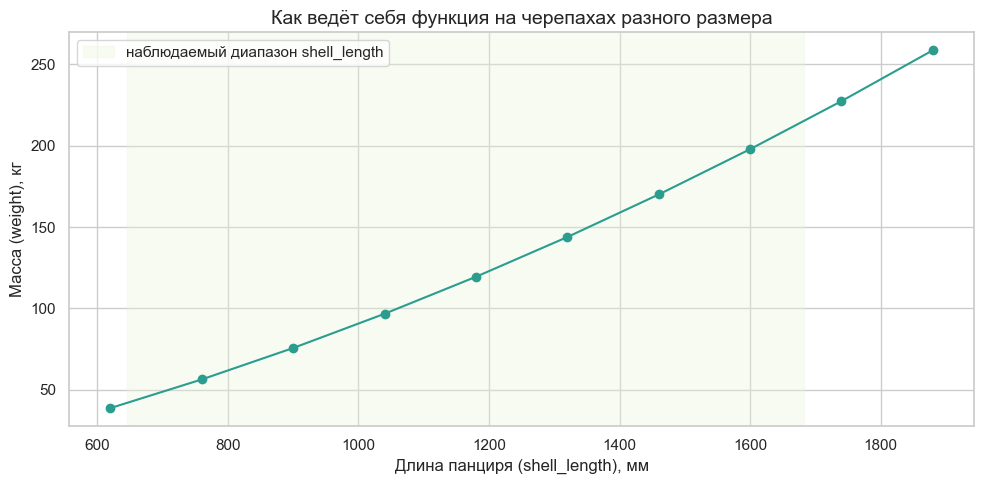

In [25]:
size_profile = {
    'shell_width_ratio': float((df_model_base['shell_width'] / df_model_base['shell_length']).median()),
    'head_length_ratio': float((df_model_base['head_length'] / df_model_base['shell_length']).median()),
    'head_width_ratio': float((df_model_base['head_width'] / df_model_base['shell_length']).median()),
}
for column in FLIPPER_LENGTH_COLUMNS:
    size_profile[f'{column}_ratio'] = float((df_model_base[column] / df_model_base['shell_length']).median())
for column in FLIPPER_WIDTH_COLUMNS:
    size_profile[f'{column}_ratio'] = float((df_model_base[column] / df_model_base['shell_length']).median())

observed_shell_min = float(df_model_base['shell_length'].min())
observed_shell_max = float(df_model_base['shell_length'].max())


def build_demo_turtle(shell_length: float, circle_count: int, note: str, measure_count: float = 2, shell_crack=None):
    turtle = {
        'shell_length': shell_length,
        'shell_width': round(shell_length * size_profile['shell_width_ratio'], 1),
        'head_length': round(shell_length * size_profile['head_length_ratio'], 1),
        'head_width': round(shell_length * size_profile['head_width_ratio'], 1),
        'circle_count': circle_count,
        'measure_count': measure_count,
        'shell_crack': shell_crack,
        'note': note,
    }
    for column in FLIPPER_LENGTH_COLUMNS:
        turtle[column] = round(shell_length * size_profile[f'{column}_ratio'], 1)
    for column in FLIPPER_WIDTH_COLUMNS:
        turtle[column] = round(shell_length * size_profile[f'{column}_ratio'], 1)
    return turtle

scenario_inputs = [
    ('small_young_turtle', build_demo_turtle(620, 12, 'маленькая молодая черепаха, короче привычного диапазона')),
    ('young_turtle', build_demo_turtle(780, 28, 'молодая черепаха среднего размера')),
    ('typical_adult_turtle', build_demo_turtle(1020, 70, 'взрослая черепаха, близкая к центру выборки')),
    ('large_adult_turtle', build_demo_turtle(1380, 105, 'крупная взрослая черепаха, но ещё в разумном диапазоне')),
    ('very_large_out_of_range_turtle', build_demo_turtle(1850, 150, 'очень крупная черепаха уже за пределами наблюдаемого диапазона')),
]

scenario_rows = []
for scenario_name, scenario_kwargs in scenario_inputs:
    kwargs = {key: value for key, value in scenario_kwargs.items() if key != 'note'}
    prediction = predict_turtle_weight(**kwargs)
    scenario_rows.append({
        'scenario': scenario_name,
        'note': scenario_kwargs['note'],
        'shell_length_mm': kwargs['shell_length'],
        'shell_width_mm': kwargs['shell_width'],
        'circle_count': kwargs['circle_count'],
        'predicted_weight_kg': round(prediction, 3),
        'inside_observed_shell_range': observed_shell_min <= kwargs['shell_length'] <= observed_shell_max,
    })

scenario_predictions = pd.DataFrame(scenario_rows).rename(columns={
    'shell_length_mm': SUMMARY_LABELS['shell_length_mm'],
    'shell_width_mm': SUMMARY_LABELS['shell_width_mm'],
    'circle_count': SUMMARY_LABELS['circle_count'],
    'predicted_weight_kg': 'Прогноз массы, кг',
    'inside_observed_shell_range': SUMMARY_LABELS['inside_observed_shell_range'],
})

typical_demo = build_demo_turtle(1020, 70, 'центр выборки')
typical_demo_x10 = typical_demo.copy()
typical_demo_x10['shell_length'] *= 10
typical_demo_x10['shell_width'] *= 10

robustness_demo = pd.DataFrame([
    {
        'case': 'typical_adult_turtle',
        'predicted_weight_kg': round(predict_turtle_weight(**{k: v for k, v in typical_demo.items() if k != 'note'}), 3),
    },
    {
        'case': 'same_adult_turtle_with_shell_x10_error',
        'predicted_weight_kg': round(predict_turtle_weight(**{k: v for k, v in typical_demo_x10.items() if k != 'note'}), 3),
    },
])
robustness_demo['difference_kg'] = (robustness_demo['predicted_weight_kg'] - robustness_demo.loc[0, 'predicted_weight_kg']).round(6)
robustness_demo = robustness_demo.rename(columns={
    'case': 'Сценарий',
    'predicted_weight_kg': 'Прогноз массы, кг',
    'difference_kg': 'Разница, кг',
})

invented_turtle = {
    'shell_length': 1111.0,
    'shell_width': 873.0,
    'head_length': 274.0,
    'head_width': 168.0,
    'flipper_length_1': 596.0,
    'flipper_width_1': 520.0,
    'flipper_length_2': 603.0,
    'flipper_width_2': 514.0,
    'flipper_length_3': 588.0,
    'flipper_width_3': 509.0,
    'flipper_length_4': 611.0,
    'flipper_width_4': 517.0,
    'circle_count': 73,
    'measure_count': float('nan'),
    'shell_crack': float('nan'),
}
invented_prepared = prepare_features_for_prediction(**invented_turtle)
invented_function_prediction = predict_turtle_weight(**invented_turtle)
invented_model_prediction = float(best_model.predict(invented_prepared)[0])
invented_turtle_check = pd.DataFrame({
    'metric': [
        'example_type',
        'shell_length_mm',
        'shell_width_mm',
        'circle_count',
        'inside_observed_shell_range',
        'prediction_via_function_kg',
        'prediction_via_model_kg',
        'abs_difference',
    ],
    'value': [
        'полностью выдуманная черепаха',
        invented_turtle['shell_length'],
        invented_turtle['shell_width'],
        invented_turtle['circle_count'],
        observed_shell_min <= invented_turtle['shell_length'] <= observed_shell_max,
        round(invented_function_prediction, 12),
        round(invented_model_prediction, 12),
        abs(invented_function_prediction - invented_model_prediction),
    ],
})
invented_turtle_check = add_summary_label_column(invented_turtle_check)

shell_grid = list(range(620, 1881, 140))
grid_predictions = []
for shell_length in shell_grid:
    turtle = build_demo_turtle(float(shell_length), circle_count=int(12 + (shell_length - 620) * (150 - 12) / (1880 - 620)), note='grid')
    grid_predictions.append({
        'shell_length_mm': shell_length,
        'predicted_weight_kg': predict_turtle_weight(**{k: v for k, v in turtle.items() if k != 'note'}),
    })
grid_predictions = pd.DataFrame(grid_predictions)

display(scenario_predictions)
display(robustness_demo)
display(invented_turtle_check)

plt.figure(figsize=(10, 5))
plt.plot(grid_predictions['shell_length_mm'], grid_predictions['predicted_weight_kg'], marker='o', color='#2a9d8f')
plt.axvspan(observed_shell_min, observed_shell_max, color='#e9f5db', alpha=0.35, label='наблюдаемый диапазон shell_length')
plt.title('Как ведёт себя функция на черепахах разного размера')
plt.xlabel(FEATURE_AXIS_LABELS['shell_length'])
plt.ylabel(FEATURE_AXIS_LABELS[TARGET_COLUMN])
plt.legend()
plt.tight_layout()
plt.show()




Этот блок нужен для простой проверки здравого смысла. Если размеры черепахи растут постепенно, прогноз массы тоже должен расти плавно, без странных скачков. Именно такую картину и видно на графике.

Сами значения тоже выглядят правдоподобно. Для небольшой молодой черепахи с `shell_length = 620` мм функция даёт около `38.8` кг. Для молодой черепахи с `780` мм уже получается `59.0` кг. Для типичной взрослой черепахи с `1020` мм прогноз равен `94.0` кг. Для крупной взрослой особи с `1380` мм он поднимается до `155.1` кг. Пока длина панциря остаётся внутри наблюдаемого диапазона, прогнозы выглядят как естественное продолжение реальных данных.

Отдельно важно посмотреть на пример с `1850` мм. Формально функция считает и такой случай, и даёт `251.9` кг, но это уже выход за знакомый диапазон наблюдений. Такой ответ лучше читать осторожно: модель умеет его посчитать, но опирается уже не на реальные похожие объекты из выборки, а на продолжение найденной линейной зависимости.

Ниже есть ещё один полезный тест: полностью выдуманная черепаха с вручную заданными размерами и пропусками в необязательных полях. Для неё прогноз через функцию и через `best_model.predict` тоже совпадает. Это хороший знак, но его важно правильно понимать. Здесь мы проверяем не качество модели, а то, что наша функция считает ту же самую формулу, что и `sklearn`. Именно поэтому нулевая разница тут не только возможна, но и ожидаема.




В конце проверю функцию уже на реальных данных из `test`. Для случайной подвыборки посчитаю прогноз двумя способами: через нашу функцию и напрямую через `best_model.predict`. Если функция написана правильно, ответы должны совпасть. Заодно станет видно, как её прогнозы соотносятся с фактической массой черепах.



,metric_ru,metric,value
0,Проверено строк test,checked_test_rows,80.000
1,Среднее расхождение функции и модели,mean_abs_difference_function_vs_model,0.000
2,Максимальное расхождение функции и модели,max_abs_difference_function_vs_model,0.000
3,MAE функции на проверенных строках,mae_to_actual_on_checked_rows,2.952


,index,"Фактическая масса, кг","Прогноз функции, кг","Прогноз модели, кг",Абсолютное расхождение
0,5211,72.565,71.261,71.261,0.000
1,2862,76.384,73.045,73.045,0.000
2,511,176.644,175.488,175.488,0.000
3,1357,110.171,114.008,114.008,0.000
4,4765,91.860,93.442,93.442,0.000
5,6037,144.472,140.699,140.699,0.000
6,7034,70.769,68.702,68.702,0.000
7,6151,100.865,107.804,107.804,0.000
8,3752,98.701,98.860,98.860,0.000
9,558,52.490,48.628,48.628,0.000


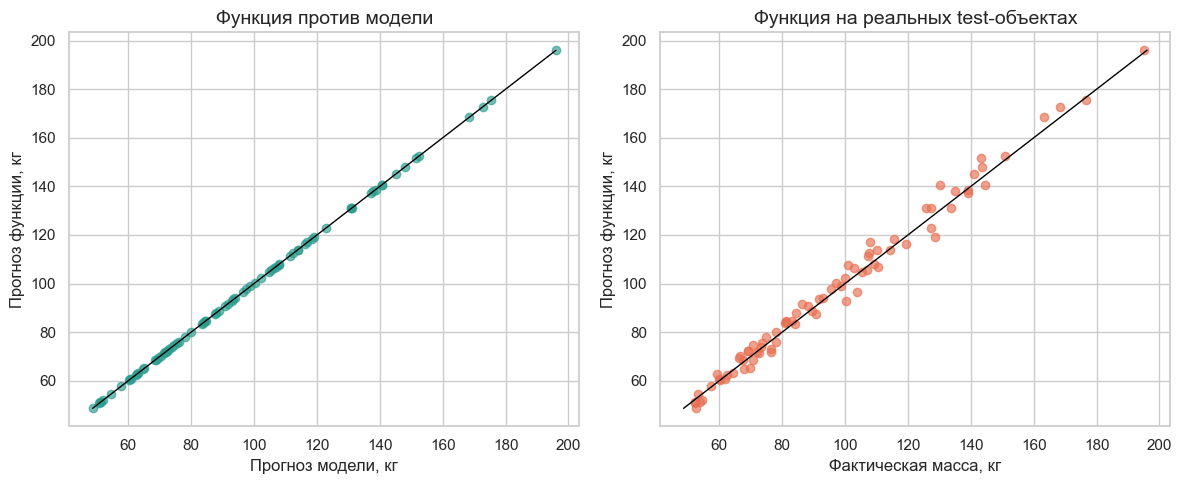

In [26]:
raw_prediction_columns = [
    'shell_length', 'shell_width', 'head_length', 'head_width',
    'flipper_length_1', 'flipper_width_1', 'flipper_length_2', 'flipper_width_2',
    'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4',
    'circle_count', 'measure_count', 'shell_crack',
]


def row_to_prediction_kwargs(row):
    return {column: row[column] for column in raw_prediction_columns}


checked_indices = X_test.sample(n=min(80, len(X_test)), random_state=RANDOM_STATE).index
real_function_rows = []
for idx in checked_indices:
    raw_row = df_model_base.loc[idx]
    kwargs = row_to_prediction_kwargs(raw_row)
    prediction_via_function = predict_turtle_weight(**kwargs)
    prediction_direct_from_model = float(best_model.predict(best_X_test.loc[[idx]])[0])
    real_function_rows.append({
        'index': idx,
        'actual_weight': raw_row[TARGET_COLUMN],
        'prediction_via_function': prediction_via_function,
        'prediction_direct_from_model': prediction_direct_from_model,
        'abs_difference': abs(prediction_via_function - prediction_direct_from_model),
    })

real_function_check = pd.DataFrame(real_function_rows).rename(columns={
    'actual_weight': 'Фактическая масса, кг',
    'prediction_via_function': 'Прогноз функции, кг',
    'prediction_direct_from_model': 'Прогноз модели, кг',
    'abs_difference': 'Абсолютное расхождение',
})
real_function_summary = pd.DataFrame({
    'metric': [
        'checked_test_rows',
        'mean_abs_difference_function_vs_model',
        'max_abs_difference_function_vs_model',
        'mae_to_actual_on_checked_rows',
    ],
    'value': [
        len(real_function_check),
        round(real_function_check['Абсолютное расхождение'].mean(), 10),
        round(real_function_check['Абсолютное расхождение'].max(), 10),
        round(mean_absolute_error(real_function_check['Фактическая масса, кг'], real_function_check['Прогноз функции, кг']), 6),
    ],
})
real_function_summary = add_summary_label_column(real_function_summary)

display(real_function_summary)
display(real_function_check.head(10).round(6))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(real_function_check['Прогноз модели, кг'], real_function_check['Прогноз функции, кг'], alpha=0.65, color='#2a9d8f')
diag_min = min(real_function_check['Прогноз модели, кг'].min(), real_function_check['Прогноз функции, кг'].min())
diag_max = max(real_function_check['Прогноз модели, кг'].max(), real_function_check['Прогноз функции, кг'].max())
axes[0].plot([diag_min, diag_max], [diag_min, diag_max], color='black', linewidth=1)
axes[0].set_title('Функция против модели')
axes[0].set_xlabel('Прогноз модели, кг')
axes[0].set_ylabel('Прогноз функции, кг')

axes[1].scatter(real_function_check['Фактическая масса, кг'], real_function_check['Прогноз функции, кг'], alpha=0.65, color='#e76f51')
actual_min = min(real_function_check['Фактическая масса, кг'].min(), real_function_check['Прогноз функции, кг'].min())
actual_max = max(real_function_check['Фактическая масса, кг'].max(), real_function_check['Прогноз функции, кг'].max())
axes[1].plot([actual_min, actual_max], [actual_min, actual_max], color='black', linewidth=1)
axes[1].set_title('Функция на реальных test-объектах')
axes[1].set_xlabel('Фактическая масса, кг')
axes[1].set_ylabel('Прогноз функции, кг')

plt.tight_layout()
plt.show()




Эта проверка нужна, чтобы убедиться, что функция работает не только на одном примере. На `80` случайных черепахах из тестовой выборки среднее и максимальное расхождение между функцией и лучшей моделью равны `0`. Это реальный и нормальный результат, потому что мы сравниваем два способа посчитать один и тот же прогноз: встроенный `best_model.predict` и нашу функцию.

Левый график показывает именно корректность реализации. Все точки лежат на диагонали, потому что прогноз функции и прогноз модели совпадают для каждого проверенного объекта. Правый график отвечает уже на другой вопрос. Он показывает, как прогнозы функции соотносятся с реальной массой черепах. Точки идут вдоль диагонали с умеренным разбросом, то есть функция сохраняет тот же уровень качества, что и сама модель, и не даёт заметного систематического смещения вверх или вниз.

Иначе говоря, нулевая разница на левом графике не означает идеальное угадывание реальной массы. Она означает, что собственная функция прогноза написана правильно. За реальное качество модели по-прежнему отвечает `MAE` относительно фактической массы.



## Общие выводы и рекомендации по дальнейшей работе

Напишите общие выводы и рекомендации по дальнейшей работе. Ответьте на вопросы:
  - Какие модели изучены?
  - Какие результаты получены?
  - Рекомендуется ли итоговая модель к внедрению?
  - Какая архитектура и способ обработки признаков показали себя лучше всего? Какие у них показатели метрик?
  - Какие признаки наиболее важны для модели?
  - Есть ли перспективы у обучения этой или других моделей для предсказания массы других видов черепах?
  - При наличии добавьте сюда свои предложения по дальнейшему развитию проекта.

Если отвечать на вопросы по итогам проекта прямо, картина получается такой.

**Какие модели изучены.**
Сначала я посмотрел на совсем простые базовые варианты `DummyRegressor(mean)` и `DummyRegressor(median)`, чтобы понять, какой уровень ошибки получается без настоящего обучения. После этого были проверены несколько линейных моделей: `LinearRegression`, `Ridge` с `alpha = 0.1`, `1`, `10`, `Lasso` с `alpha = 0.0001`, `0.001`, `0.01` и `SGDRegressor` с разными функциями потерь, `squared_error`, `epsilon_insensitive` и `huber`. Каждая конфигурация сравнивалась на трёх вариантах подготовки признаков: без масштабирования, со стандартизацией и с нормализацией min-max. Отдельно я сравнил два набора признаков: только базовые измерения и базовые измерения вместе с инженерными признаками.

**Какие результаты получены.**
Главный вывод здесь простой: решающую роль сыграли не сложные настройки модели, а качественная подготовка данных. После очистки, исправления x10-ошибки у панциря и добавления инженерных признаков качество заметно выросло. Лучшей конфигурацией стала `Lasso(alpha=0.001)` на стандартизованных признаках и расширенном наборе признаков. На взрослых черепахах `50-150` кг, а это главный практический диапазон, модель даёт `MAE = 2.943` кг на `validation` и `2.923` кг на `test`. По всем объектам метрики тоже сильные: `MAE = 3.264` кг на `validation` и `3.271` кг на `test`, `MAPE = 3.4%` и `3.3%`, `R² = 0.986` и `0.984`.

**Какая архитектура и обработка признаков показали себя лучше всего.**
Лучше всего сработала линейная модель с лёгкой L1-регуляризацией, стандартизацией признаков и расширенным набором признаков. При честном сравнении, когда фиксированы и модель, и способ масштабирования, переход от базовых измерений к расширенному набору (`basic_plus_engineered`) снижает `adult MAE` с `3.496` до `2.943` кг. Это выигрыш примерно `553` грамма, или `15.8%`. То есть в этом проекте основной прирост качества дали как раз удачные признаки, а не попытка найти какую-то экзотическую архитектуру.

**Насколько различаются лучшие модели.**
`Lasso`, `Ridge` и обычная `LinearRegression` здесь идут почти рядом. Разница между ними уже очень маленькая. Поэтому было бы нечестно делать вид, что `Lasso` радикально сильнее остальных. Я выбрал её как аккуратного лидера: у неё лучший `MAE`, она чуть лучше держится на валидации и тесте и при этом даёт более собранную модель за счёт регуляризации. А вот `SGDRegressor` оказался полезен скорее как учебное сравнение. Он работает приемлемо, но уступает лучшим линейным решениям и сильнее зависит от масштабирования.

**Какие признаки важнее всего.**
Если смотреть на абсолютные коэффициенты лучшей модели, то основной вклад дают признаки, которые описывают общий размер тела: средняя площадь ласт (`flipper_area_mean`), длина панциря (`shell_length`), ширина панциря (`shell_width`), площадь головы (`head_area`) и площадь панциря (`shell_area`). Это хорошо совпадает и с корреляционным анализом. При этом интерпретировать их как строгий биологический рейтинг нужно осторожно, потому что часть размерных признаков заметно коррелирует между собой. Здесь надёжнее такой вывод: чем крупнее панцирь, голова и ласты, тем выше ожидаемая масса.

**Рекомендуется ли модель к внедрению.**
Для `Chelonia mydas` я бы рекомендовал эту модель как рабочий первый вариант. Она уверенно проходит целевые пороги, `MAE` на взрослом диапазоне заметно ниже `5` кг, а качество на `test` почти не хуже, чем на `validation`. При этом важно не переоценивать результат: внедрять её разумно именно как модель для этого вида и только вместе с проверками входных данных, чтобы ошибки масштаба вроде x10 отлавливались до прогноза.



**Есть ли перспектива для других видов и что делать дальше.**

У этой работы точно есть продолжение. Но я бы не переносил текущую модель на другие виды черепах автоматически. Сначала лучше собрать по ним достаточно чистых наблюдений и понять, сохраняются ли те же зависимости между размерами и массой. На практике я бы проверял два пути: отдельные модели по видам и общую модель с явным учётом признака вида. Уже после этого можно честно сравнить, что работает лучше.

Если говорить про развитие именно этого проекта, то самые полезные следующие шаги выглядят так.

1. Встроить автоматическую проверку размеров панциря при загрузке данных, чтобы x10-ошибка ловилась сразу, а не уже на этапе анализа.
2. Продолжить работу над признаками. Здесь уже видно, что площади и агрегаты помогают, значит есть смысл проверить новые интерпретируемые признаки, например пропорции тела и асимметрию ласт.
3. Улучшить сбор признака `shell_crack`, потому что сейчас у него много пропусков и из-за этого его сигнал используется не в полную силу.
4. Собрать больше наблюдений по крайним зонам, по очень маленьким и очень крупным черепахам. Это особенно важно для более уверенной работы модели за пределами центральной части выборки.
5. После этого можно снова сравнить линейные модели с более сложными подходами. Но уже на чистых данных и с понятной точкой отсчёта, потому что сейчас линейная модель и так решает задачу очень достойно.

Итог для меня такой: проект уже выглядит как хорошая рабочая базовая модель, а не как учебный черновик. Самый сильный результат здесь не в том, что удалось подобрать одну удачную модель, а в том, что удалось аккуратно пройти весь путь: от проверки данных до интерпретируемого и воспроизводимого прогноза.

**Ссылка на публичный репозиторий проекта:** https://github.com/neiro/ds-tortila

